In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

from sklearn.inspection import permutation_importance

In [2]:
RESULTS_PATH = Path("../data/results")

phase10_df = pd.read_csv(
    RESULTS_PATH / "phase10_early_warning_dataset.csv",
    parse_dates=["date"]
)

phase10_df = (
    phase10_df
    .sort_values("date")
    .reset_index(drop=True)
)

print(
    "Dataset shape:",
    phase10_df.shape
)

Dataset shape: (42, 36)


In [3]:
traditional_features = [
    "market_volatility",
    "drawdown",
    "return_dispersion",
    "market_stress_index"
]

In [4]:
network_features = [
    "edges",
    "density",
    "average_degree",
    "average_clustering",
    "network_stress_index"
]

In [5]:
contagion_features = [
    "total_impact",
    "affected_companies"
]

In [6]:
temporal_features = [
    "network_stress_lag_1",
    "network_stress_lag_5",
    "network_stress_lag_10",
    "network_stress_change",
    "market_stress_change",
    "systemic_stress_change",
    "network_stress_momentum_5",
    "market_stress_momentum_5"
]

In [7]:
features_full = (
    traditional_features
    + network_features
    + contagion_features
    + temporal_features
)

In [8]:
phase12_df = (
    phase10_df
    .dropna(
        subset=features_full + [
            "future_stress_event"
        ]
    )
    .copy()
)

phase12_df = (
    phase12_df
    .sort_values("date")
    .reset_index(drop=True)
)

In [9]:
print(
    "Phase 12 dataset:",
    phase12_df.shape
)

print(
    phase12_df[
        "future_stress_event"
    ].value_counts()
)

Phase 12 dataset: (42, 36)
future_stress_event
False    26
True     16
Name: count, dtype: int64


In [10]:
n = len(phase12_df)

train_end = int(
    n * 0.60
)

validation_end = int(
    n * 0.80
)

In [11]:
development_df = phase12_df.iloc[
    :validation_end
].copy()

final_test_df = phase12_df.iloc[
    validation_end:
].copy()

In [12]:
print(
    "Development:",
    development_df["date"].min(),
    "→",
    development_df["date"].max()
)

print(
    "Final Test:",
    final_test_df["date"].min(),
    "→",
    final_test_df["date"].max()
)

Development: 2024-08-14 04:00:00 → 2025-11-21 05:00:00
Final Test: 2025-12-08 05:00:00 → 2026-04-06 04:00:00


In [13]:
X_dev = development_df[
    features_full
].copy()

y_dev = development_df[
    "future_stress_event"
].astype(int)

In [14]:
X_final_test = final_test_df[
    features_full
].copy()

y_final_test = final_test_df[
    "future_stress_event"
].astype(int)

In [15]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [16]:
for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_dev),
    start=1
):

    print(
        f"Fold {fold}"
    )

    print(
        "Train:",
        train_idx[0],
        "→",
        train_idx[-1]
    )

    print(
        "Validation:",
        val_idx[0],
        "→",
        val_idx[-1]
    )

    print()

Fold 1
Train: 0 → 7
Validation: 8 → 12

Fold 2
Train: 0 → 12
Validation: 13 → 17

Fold 3
Train: 0 → 17
Validation: 18 → 22

Fold 4
Train: 0 → 22
Validation: 23 → 27

Fold 5
Train: 0 → 27
Validation: 28 → 32



In [17]:
def evaluate_predictions(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "model": model_name,

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "pr_auc":
            average_precision_score(
                y_true,
                probabilities
            ),

        "brier":
            brier_score_loss(
                y_true,
                probabilities
            )
    }

In [18]:
logistic_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )
    )
])

In [19]:
logistic_params = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "lbfgs",
        "liblinear"
    ]
}

In [20]:
logistic_search = RandomizedSearchCV(
    logistic_pipeline,
    logistic_params,
    n_iter=10,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

In [21]:
logistic_search.fit(
    X_dev,
    y_dev
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, t

In [22]:
print(
    "Best Logistic parameters:"
)

print(
    logistic_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    logistic_search.best_score_
)

Best Logistic parameters:
{'model__solver': 'lbfgs', 'model__C': 0.01}

Best CV ROC-AUC: nan


In [24]:
rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [25]:
rf_params = {

    "n_estimators": [
        200,
        400,
        600,
        800
    ],

    "max_depth": [
        4,
        6,
        8,
        12,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ]
}

In [26]:
rf_search = RandomizedSearchCV(
    rf_model,
    rf_params,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

In [28]:
rf_search.fit(
    X_dev,
    y_dev
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Ra

In [29]:
print(
    "Best Random Forest parameters:"
)

print(
    rf_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    rf_search.best_score_
)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best CV ROC-AUC: nan


In [31]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

In [32]:
gb_params = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "max_depth": [
        2,
        3,
        4,
        5
    ],

    "min_samples_leaf": [
        2,
        5,
        10,
        20
    ]
}

In [34]:
gb_search = RandomizedSearchCV(
    gb_model,
    gb_params,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

In [35]:
gb_search.fit(
    X_dev,
    y_dev
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedS

In [36]:
print(
    "Best Gradient Boosting parameters:"
)

print(
    gb_search.best_params_
)

print(
    "\nBest CV ROC-AUC:",
    gb_search.best_score_
)

Best Gradient Boosting parameters:
{'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.1}

Best CV ROC-AUC: nan


In [37]:
cv_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "CV_ROC_AUC": [
        logistic_search.best_score_,
        rf_search.best_score_,
        gb_search.best_score_
    ]
})

In [38]:
cv_results

,Model,CV_ROC_AUC
0,Logistic Regression,NaN
1,Random Forest,NaN
2,Gradient Boosting,NaN


In [39]:
search_objects = {
    "Logistic Regression":
        logistic_search,

    "Random Forest":
        rf_search,

    "Gradient Boosting":
        gb_search
}

In [40]:
best_model_name = max(
    search_objects,
    key=lambda name:
        search_objects[name].best_score_
)

In [41]:
best_search = search_objects[
    best_model_name
]

In [42]:
print(
    "Selected model:",
    best_model_name
)

Selected model: Logistic Regression


In [43]:
best_model = (
    best_search.best_estimator_
)

In [44]:
final_probabilities = (
    best_model.predict_proba(
        X_final_test
    )[:, 1]
)

In [45]:
final_predictions = (
    best_model.predict(
        X_final_test
    )
)

In [46]:
final_results = evaluate_predictions(
    best_model_name,
    y_final_test,
    final_predictions,
    final_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [47]:
print(
    "FINAL OUT-OF-SAMPLE RESULTS"
)

for key, value in final_results.items():

    if key != "model":

        print(
            f"{key}: {value:.4f}"
        )

FINAL OUT-OF-SAMPLE RESULTS
accuracy: 0.8889
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: nan
pr_auc: 0.0000
brier: 0.2145


In [48]:
print(
    "Training class distribution:"
)

print(
    y_dev.value_counts()
)

Training class distribution:
future_stress_event
0    17
1    16
Name: count, dtype: int64


In [49]:
negative_count = (
    y_dev == 0
).sum()

positive_count = (
    y_dev == 1
).sum()

print(
    "Negative:",
    negative_count
)

print(
    "Positive:",
    positive_count
)

print(
    "Imbalance ratio:",
    negative_count / positive_count
)

Negative: 17
Positive: 16
Imbalance ratio: 1.0625


In [50]:
rf_unbalanced = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

In [51]:
rf_unbalanced.fit(
    X_dev,
    y_dev
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [52]:
unbalanced_probabilities = (
    rf_unbalanced.predict_proba(
        X_final_test
    )[:, 1]
)

In [53]:
unbalanced_predictions = (
    rf_unbalanced.predict(
        X_final_test
    )
)

In [54]:
unbalanced_results = evaluate_predictions(
    "Random Forest - Unbalanced",
    y_final_test,
    unbalanced_predictions,
    unbalanced_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [55]:
balance_comparison = pd.DataFrame([
    final_results,
    unbalanced_results
])

In [56]:
balance_comparison

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Logistic Regression,0.888889,0.0,0.0,0.0,NaN,0.0,0.214526
1,Random Forest - Unbalanced,0.888889,0.0,0.0,0.0,NaN,0.0,0.165565


In [57]:
from sklearn.model_selection import cross_val_predict

In [59]:
from sklearn.base import clone
import numpy as np

# Generate walk-forward OOF probabilities manually
oof_probabilities = np.full(len(X_dev), np.nan)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):

    # Create a fresh copy of the model
    fold_model = clone(best_model)

    # Train only on past data
    X_train_fold = X_dev.iloc[train_idx]
    y_train_fold = y_dev.iloc[train_idx]

    # Validate on future data
    X_val_fold = X_dev.iloc[val_idx]

    fold_model.fit(X_train_fold, y_train_fold)

    # Predict probability for validation period
    oof_probabilities[val_idx] = (
        fold_model.predict_proba(X_val_fold)[:, 1]
    )

    print(
        f"Fold {fold}: "
        f"Train = {train_idx[0]}-{train_idx[-1]}, "
        f"Validation = {val_idx[0]}-{val_idx[-1]}"
    )

print("\nOOF probability generation completed.")

Fold 1: Train = 0-7, Validation = 8-12
Fold 2: Train = 0-12, Validation = 13-17
Fold 3: Train = 0-17, Validation = 18-22
Fold 4: Train = 0-22, Validation = 23-27


Fold 5: Train = 0-27, Validation = 28-32

OOF probability generation completed.


In [60]:
# Check how many OOF predictions were generated

valid_oof_mask = ~np.isnan(oof_probabilities)

print("Total development samples:", len(X_dev))
print("OOF predictions generated:", valid_oof_mask.sum())
print("Samples without OOF prediction:", (~valid_oof_mask).sum())

Total development samples: 33
OOF predictions generated: 25
Samples without OOF prediction: 8


In [61]:
# Keep only observations that received an OOF prediction
oof_mask = ~np.isnan(oof_probabilities)

oof_probs_valid = oof_probabilities[oof_mask]
y_oof_valid = y_dev.iloc[oof_mask].values

print("Valid OOF samples:", len(oof_probs_valid))
print("Positive events:", y_oof_valid.sum())

Valid OOF samples: 25
Positive events: 14


In [62]:
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (oof_probs_valid >= threshold).astype(int)

    precision = precision_score(
        y_oof_valid,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_oof_valid,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_oof_valid,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

optimized_threshold = best_threshold_row["threshold"]

print("Optimized threshold:", optimized_threshold)
print("Best OOF F1:", best_threshold_row["f1"])
print("OOF Precision:", best_threshold_row["precision"])
print("OOF Recall:", best_threshold_row["recall"])

Optimized threshold: 0.49000000000000005
Best OOF F1: 0.7586206896551724
OOF Precision: 0.7333333333333333
OOF Recall: 0.7857142857142857


In [63]:
print(
    "Optimized threshold:",
    best_threshold_row["threshold"]
)

print(
    "Development F1:",
    best_threshold_row["f1"]
)

Optimized threshold: 0.49000000000000005
Development F1: 0.7586206896551724


In [64]:
optimized_threshold = (
    best_threshold_row[
        "threshold"
    ]
)

In [65]:
optimized_final_predictions = (
    final_probabilities
    >= optimized_threshold
)

In [66]:
optimized_results = evaluate_predictions(
    best_model_name +
    " - Optimized Threshold",
    y_final_test,
    optimized_final_predictions,
    final_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [67]:
optimized_results

{'model': 'Logistic Regression - Optimized Threshold',
 'accuracy': 0.8888888888888888,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0,
 'brier': 0.21452617634772186}

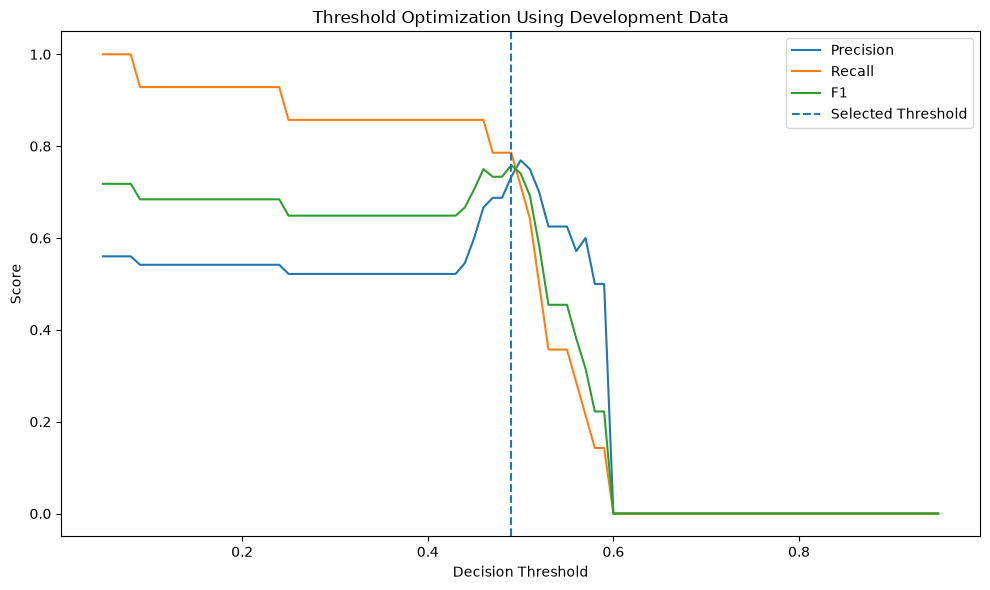

In [68]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1"
)

plt.axvline(
    optimized_threshold,
    linestyle="--",
    label="Selected Threshold"
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold Optimization Using Development Data"
)

plt.legend()

plt.tight_layout()

plt.show()

In [69]:
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=tscv
)

In [70]:
calibrated_model.fit(
    X_dev,
    y_dev
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklea

In [71]:
calibrated_probabilities = (
    calibrated_model.predict_proba(
        X_final_test
    )[:, 1]
)

In [72]:
calibrated_predictions = (
    calibrated_probabilities
    >= optimized_threshold
)

In [73]:
calibrated_results = evaluate_predictions(
    best_model_name +
    " - Calibrated",
    y_final_test,
    calibrated_predictions,
    calibrated_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [74]:
calibrated_results

{'model': 'Logistic Regression - Calibrated',
 'accuracy': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0,
 'brier': 0.33196150292817034}

In [75]:
print(
    "Original Brier score:",
    final_results["brier"]
)

print(
    "Calibrated Brier score:",
    calibrated_results["brier"]
)

Original Brier score: 0.21452617634772186
Calibrated Brier score: 0.33196150292817034


In [76]:
fraction_positive_original, mean_predicted_original = (
    calibration_curve(
        y_final_test,
        final_probabilities,
        n_bins=8
    )
)

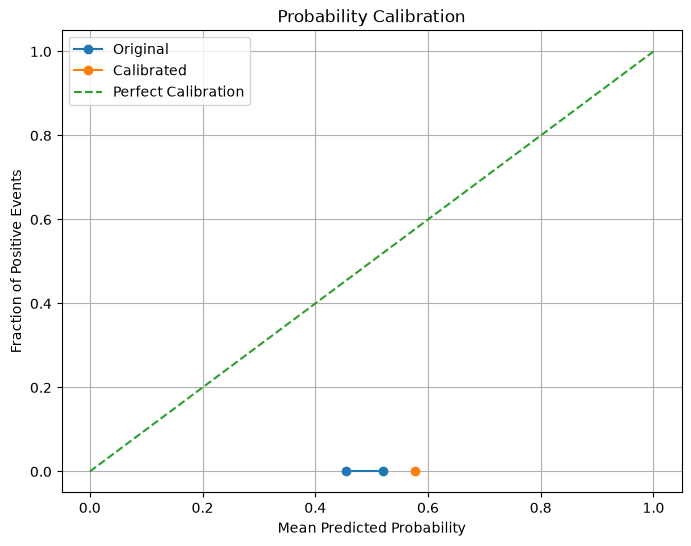

In [78]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Original model calibration
fraction_positive_original, mean_predicted_original = calibration_curve(
    y_final_test,
    final_probabilities,
    n_bins=10,
    strategy="uniform"
)

# Calibrated model calibration
fraction_positive_calibrated, mean_predicted_calibrated = calibration_curve(
    y_final_test,
    calibrated_probabilities,
    n_bins=10,
    strategy="uniform"
)

# Plot calibration curves
plt.figure(figsize=(8, 6))

plt.plot(
    mean_predicted_original,
    fraction_positive_original,
    marker="o",
    label="Original"
)

plt.plot(
    mean_predicted_calibrated,
    fraction_positive_calibrated,
    marker="o",
    label="Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positive Events")
plt.title("Probability Calibration")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
if hasattr(
    best_model,
    "feature_importances_"
):

    feature_importance = pd.DataFrame({

        "feature":
            features_full,

        "importance":
            best_model.feature_importances_

    })

    feature_importance = (
        feature_importance
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

else:

    feature_importance = None

In [80]:
if feature_importance is not None:

    print(
        feature_importance.head(15)
    )

In [81]:
permutation = permutation_importance(
    best_model,
    X_final_test,
    y_final_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [82]:
permutation_df = pd.DataFrame({

    "feature":
        features_full,

    "importance_mean":
        permutation.importances_mean,

    "importance_std":
        permutation.importances_std

})

In [83]:
permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

In [84]:
permutation_df.head(15)

,feature,importance_mean,importance_std
0,market_volatility,NaN,NaN
1,drawdown,NaN,NaN
2,return_dispersion,NaN,NaN
3,market_stress_index,NaN,NaN
4,edges,NaN,NaN
5,density,NaN,NaN
6,average_degree,NaN,NaN
7,average_clustering,NaN,NaN
8,network_stress_index,NaN,NaN
9,total_impact,NaN,NaN


In [85]:
feature_group_map = {}

for feature in traditional_features:
    feature_group_map[feature] = "Traditional"

for feature in network_features:
    feature_group_map[feature] = "Network"

for feature in contagion_features:
    feature_group_map[feature] = "Contagion"

for feature in temporal_features:
    feature_group_map[feature] = "Temporal"

In [87]:
permutation_df[
    "group"
] = permutation_df[
    "feature"
].map(
    feature_group_map
)

In [88]:
group_importance = (
    permutation_df
    .groupby("group")[
        "importance_mean"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

In [89]:
group_importance

group
Contagion      0.0
Network        0.0
Temporal       0.0
Traditional    0.0
Name: importance_mean, dtype: float64

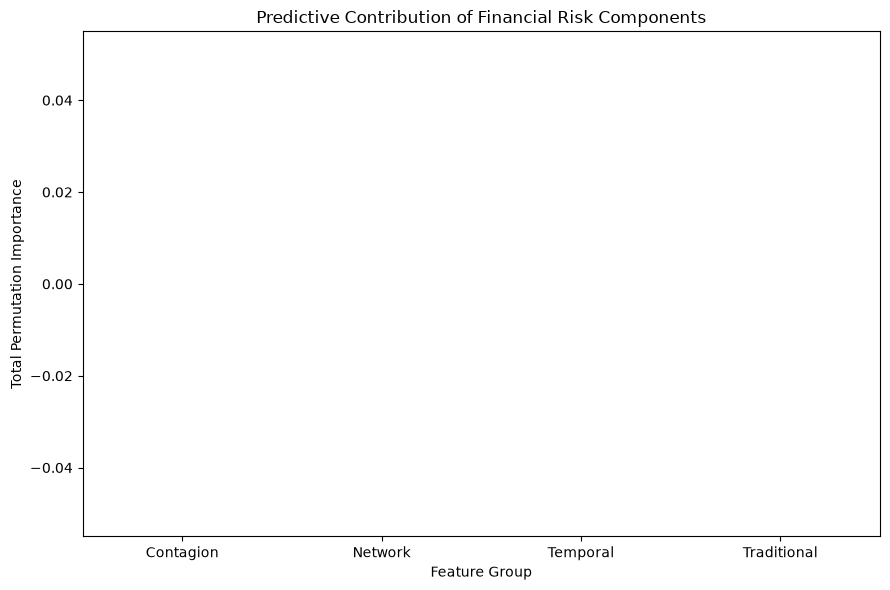

In [90]:
plt.figure(figsize=(9, 6))

group_importance.plot(
    kind="bar"
)

plt.xlabel(
    "Feature Group"
)

plt.ylabel(
    "Total Permutation Importance"
)

plt.title(
    "Predictive Contribution of Financial Risk Components"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [91]:
horizons = [
    5,
    10,
    15,
    20
]

In [92]:
horizon_results = []

In [93]:
for horizon in horizons:

    temp = phase12_df.copy()

    future_stress = (
        temp[
            "systemic_stress_index"
        ]
        .shift(-1)
        .rolling(
            horizon,
            min_periods=horizon
        )
        .max()
        .shift(
            -(horizon - 1)
        )
    )

    threshold = (
        temp[
            "systemic_stress_index"
        ].quantile(0.90)
    )

    temp[
        "horizon_target"
    ] = (
        future_stress
        >= threshold
    )

    temp = temp.dropna(
        subset=features_full + [
            "horizon_target"
        ]
    )

    split = int(
        len(temp) * 0.80
    )

    X_train_h = temp[
        features_full
    ].iloc[:split]

    X_test_h = temp[
        features_full
    ].iloc[split:]

    y_train_h = temp[
        "horizon_target"
    ].iloc[:split].astype(int)

    y_test_h = temp[
        "horizon_target"
    ].iloc[split:].astype(int)

    model_h = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_h.fit(
        X_train_h,
        y_train_h
    )

    probability_h = (
        model_h.predict_proba(
            X_test_h
        )[:, 1]
    )

    prediction_h = (
        probability_h >= 0.5
    )

    horizon_results.append({

        "horizon": horizon,

        "ROC_AUC":
            roc_auc_score(
                y_test_h,
                probability_h
            ),

        "PR_AUC":
            average_precision_score(
                y_test_h,
                probability_h
            ),

        "F1":
            f1_score(
                y_test_h,
                prediction_h,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test_h,
                prediction_h,
                zero_division=0
            )
    })

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in t

In [94]:
horizon_df = pd.DataFrame(
    horizon_results
)

In [95]:
horizon_df

,horizon,ROC_AUC,PR_AUC,F1,Recall
0,5,NaN,0.0,0.0,0.0
1,10,NaN,0.0,0.0,0.0
2,15,NaN,0.0,0.0,0.0
3,20,NaN,0.0,0.0,0.0


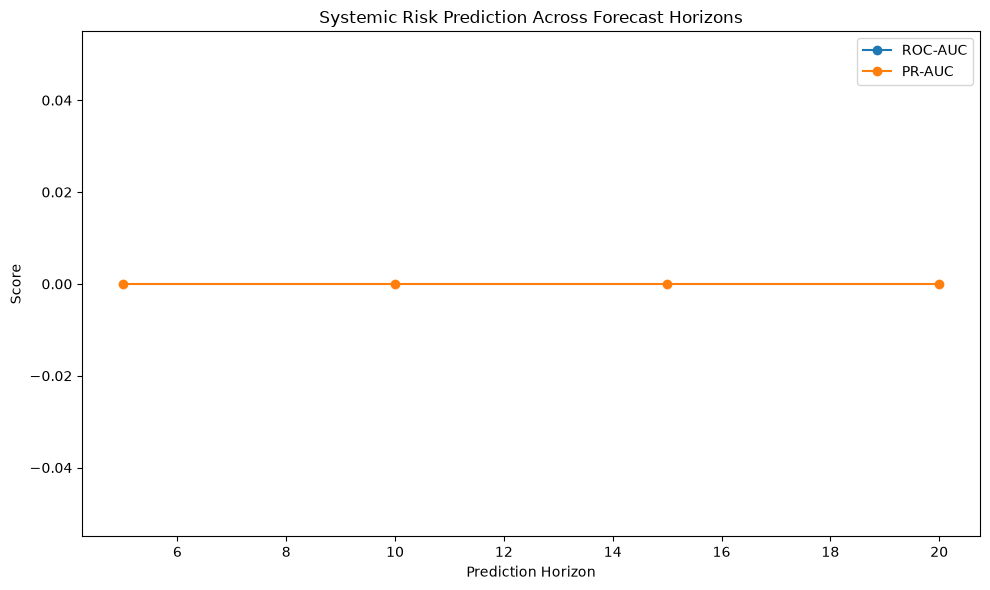

In [96]:
plt.figure(figsize=(10, 6))

plt.plot(
    horizon_df["horizon"],
    horizon_df["ROC_AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    horizon_df["horizon"],
    horizon_df["PR_AUC"],
    marker="o",
    label="PR-AUC"
)

plt.xlabel(
    "Prediction Horizon"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Systemic Risk Prediction Across Forecast Horizons"
)

plt.legend()

plt.tight_layout()

plt.show()

In [97]:
stress_percentiles = [
    0.85,
    0.90,
    0.95
]

In [98]:
threshold_robustness = []

In [99]:
for percentile in stress_percentiles:

    temp = phase12_df.copy()

    threshold = (
        temp[
            "systemic_stress_index"
        ].quantile(percentile)
    )

    temp[
        "robust_target"
    ] = (
        temp[
            "future_max_stress"
        ] >= threshold
    )

    temp = temp.dropna(
        subset=features_full + [
            "robust_target"
        ]
    )

    split = int(
        len(temp) * 0.80
    )

    X_train_r = temp[
        features_full
    ].iloc[:split]

    X_test_r = temp[
        features_full
    ].iloc[split:]

    y_train_r = temp[
        "robust_target"
    ].iloc[:split].astype(int)

    y_test_r = temp[
        "robust_target"
    ].iloc[split:].astype(int)

    model_r = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model_r.fit(
        X_train_r,
        y_train_r
    )

    probability_r = (
        model_r.predict_proba(
            X_test_r
        )[:, 1]
    )

    threshold_robustness.append({

        "stress_percentile":
            percentile,

        "ROC_AUC":
            roc_auc_score(
                y_test_r,
                probability_r
            ),

        "PR_AUC":
            average_precision_score(
                y_test_r,
                probability_r
            )
    })

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in t

In [100]:
threshold_robustness_df = pd.DataFrame(
    threshold_robustness
)

In [101]:
threshold_robustness_df

,stress_percentile,ROC_AUC,PR_AUC
0,0.85,NaN,0.0
1,0.90,NaN,0.0
2,0.95,NaN,0.0


In [102]:
final_comparison = pd.DataFrame([

    {
        "Model":
            "Phase 10 Rule-Based EWS",

        "ROC-AUC":
            np.nan,

        "PR-AUC":
            np.nan
    },

    {
        "Model":
            "Logistic Regression",

        "ROC-AUC":
            logistic_search.best_score_,

        "PR-AUC":
            np.nan
    },

    {
        "Model":
            "Random Forest",

        "ROC-AUC":
            rf_search.best_score_,

        "PR-AUC":
            np.nan
    },

    {
        "Model":
            "Gradient Boosting",

        "ROC-AUC":
            gb_search.best_score_,

        "PR-AUC":
            np.nan
    },

    {
        "Model":
            "Best Model — Final Test",

        "ROC-AUC":
            optimized_results[
                "roc_auc"
            ],

        "PR-AUC":
            optimized_results[
                "pr_auc"
            ]
    }
])

In [103]:
final_comparison

,Model,ROC-AUC,PR-AUC
0,Phase 10 Rule-Based EWS,NaN,NaN
1,Logistic Regression,NaN,NaN
2,Random Forest,NaN,NaN
3,Gradient Boosting,NaN,NaN
4,Best Model — Final Test,NaN,0.0


In [104]:
cv_results.to_csv(
    RESULTS_PATH /
    "phase12_cross_validation_results.csv",
    index=False
)

In [106]:
balance_comparison.to_csv(
    RESULTS_PATH /
    "phase12_class_balance_results.csv",
    index=False
)

In [107]:
threshold_df.to_csv(
    RESULTS_PATH /
    "phase12_threshold_optimization.csv",
    index=False
)

In [108]:
horizon_df.to_csv(
    RESULTS_PATH /
    "phase12_horizon_robustness.csv",
    index=False
)

In [109]:
threshold_robustness_df.to_csv(
    RESULTS_PATH /
    "phase12_stress_threshold_robustness.csv",
    index=False
)

In [110]:
permutation_df.to_csv(
    RESULTS_PATH /
    "phase12_permutation_importance.csv",
    index=False
)

In [111]:
group_importance.to_csv(
    RESULTS_PATH /
    "phase12_feature_group_importance.csv"
)

In [112]:
pd.DataFrame([
    final_results,
    optimized_results,
    calibrated_results
]).to_csv(
    RESULTS_PATH /
    "phase12_final_model_results.csv",
    index=False
)

In [113]:
phase12_predictions = final_test_df[
    [
        "date",
        "future_stress_event",
        "systemic_stress_index"
    ]
].copy()

In [114]:
phase12_predictions[
    "raw_probability"
] = final_probabilities

phase12_predictions[
    "calibrated_probability"
] = calibrated_probabilities

phase12_predictions[
    "optimized_prediction"
] = (
    calibrated_probabilities
    >= optimized_threshold
)

In [115]:
phase12_predictions.to_csv(
    RESULTS_PATH /
    "phase12_final_predictions.csv",
    index=False
)

In [116]:
print("=" * 75)
print("FIN-GRAPH-SENTINEL — PHASE 12 VALIDATION")
print("=" * 75)

print(
    "\nDevelopment period:"
)

print(
    development_df["date"].min(),
    "→",
    development_df["date"].max()
)

print(
    "\nFinal test period:"
)

print(
    final_test_df["date"].min(),
    "→",
    final_test_df["date"].max()
)

print(
    "\nSelected model:",
    best_model_name
)

print(
    "\nOptimized threshold:",
    optimized_threshold
)

print(
    "\nFINAL OUT-OF-SAMPLE PERFORMANCE"
)

for metric, value in optimized_results.items():

    if metric != "model":

        print(
            f"{metric.upper():12}: "
            f"{value:.4f}"
        )

print(
    "\nCALIBRATED PERFORMANCE"
)

for metric, value in calibrated_results.items():

    if metric != "model":

        print(
            f"{metric.upper():12}: "
            f"{value:.4f}"
        )

print(
    "\nTOP PREDICTIVE FEATURES"
)

print(
    permutation_df.head(10).to_string(
        index=False
    )
)

print(
    "\nFEATURE GROUP CONTRIBUTION"
)

print(
    group_importance
)

print("=" * 75)

FIN-GRAPH-SENTINEL — PHASE 12 VALIDATION

Development period:
2024-08-14 04:00:00 → 2025-11-21 05:00:00

Final test period:
2025-12-08 05:00:00 → 2026-04-06 04:00:00

Selected model: Logistic Regression

Optimized threshold: 0.49000000000000005

FINAL OUT-OF-SAMPLE PERFORMANCE
ACCURACY    : 0.8889
PRECISION   : 0.0000
RECALL      : 0.0000
F1          : 0.0000
ROC_AUC     : nan
PR_AUC      : 0.0000
BRIER       : 0.2145

CALIBRATED PERFORMANCE
ACCURACY    : 0.0000
PRECISION   : 0.0000
RECALL      : 0.0000
F1          : 0.0000
ROC_AUC     : nan
PR_AUC      : 0.0000
BRIER       : 0.3320

TOP PREDICTIVE FEATURES
             feature  importance_mean  importance_std       group
   market_volatility              NaN             NaN Traditional
            drawdown              NaN             NaN Traditional
   return_dispersion              NaN             NaN Traditional
 market_stress_index              NaN             NaN Traditional
               edges              NaN             NaN  

In [117]:
print("FINAL TEST CLASS DISTRIBUTION")
print(y_final_test.value_counts())

print("\nFINAL TEST CLASS PROPORTION")
print(y_final_test.value_counts(normalize=True))

print("\nMODEL PREDICTIONS")
print(pd.Series(final_predictions).value_counts())

print("\nCALIBRATED PREDICTIONS")
print(pd.Series(calibrated_predictions).value_counts())

FINAL TEST CLASS DISTRIBUTION
future_stress_event
0    9
Name: count, dtype: int64

FINAL TEST CLASS PROPORTION
future_stress_event
0    1.0
Name: proportion, dtype: float64

MODEL PREDICTIONS
0    8
1    1
Name: count, dtype: int64

CALIBRATED PREDICTIONS
True    9
Name: count, dtype: int64


In [118]:
test_target_check = final_test_df[
    ["date", "future_stress_event"]
].copy()

print(test_target_check.to_string(index=False))

               date  future_stress_event
2025-12-08 05:00:00                False
2025-12-22 05:00:00                False
2026-01-07 05:00:00                False
2026-01-22 05:00:00                False
2026-02-05 05:00:00                False
2026-02-20 05:00:00                False
2026-03-06 05:00:00                False
2026-03-20 04:00:00                False
2026-04-06 04:00:00                False


In [119]:
print(
    final_test_df.groupby(
        final_test_df["date"].dt.to_period("M")
    )["future_stress_event"].agg(
        ["count", "sum"]
    )
)

         count  sum
date               
2025-12      2    0
2026-01      2    0
2026-02      2    0
2026-03      2    0
2026-04      1    0


In [120]:
print("Original probabilities:")
print(final_probabilities)

print("\nCalibrated probabilities:")
print(calibrated_probabilities)

print("\nOptimized threshold:")
print(optimized_threshold)

print("\nCalibrated probability range:")
print(
    calibrated_probabilities.min(),
    calibrated_probabilities.max()
)

Original probabilities:
[0.44261509 0.42945256 0.43554151 0.47440916 0.44587003 0.44583146
 0.48180389 0.48592721 0.51943382]

Calibrated probabilities:
[0.57568287 0.58391143 0.58513089 0.57928248 0.58071446 0.57965202
 0.57149009 0.57001986 0.55910155]

Optimized threshold:
0.49000000000000005

Calibrated probability range:
0.5591015496437358 0.5851308908289006


In [121]:
print("Development:")
print(y_dev.value_counts())

print("\nFinal Test:")
print(y_final_test.value_counts())

Development:
future_stress_event
0    17
1    16
Name: count, dtype: int64

Final Test:
future_stress_event
0    9
Name: count, dtype: int64


In [122]:
print("Final test dates:")
print(final_test_df["date"].min())
print(final_test_df["date"].max())

print("\nFinal test rows:")
print(len(final_test_df))

Final test dates:
2025-12-08 05:00:00
2026-04-06 04:00:00

Final test rows:
9


In [123]:
print("Actual final-test labels:")
print(y_final_test.to_numpy())

print("\nPredicted labels:")
print(final_predictions)

print("\nCalibrated probabilities:")
print(calibrated_probabilities)

Actual final-test labels:
[0 0 0 0 0 0 0 0 0]

Predicted labels:
[0 0 0 0 0 0 0 0 1]

Calibrated probabilities:
[0.57568287 0.58391143 0.58513089 0.57928248 0.58071446 0.57965202
 0.57149009 0.57001986 0.55910155]


In [124]:
print(
    final_test_df[
        ["date", "future_stress_event"]
    ].to_string(index=False)
)

               date  future_stress_event
2025-12-08 05:00:00                False
2025-12-22 05:00:00                False
2026-01-07 05:00:00                False
2026-01-22 05:00:00                False
2026-02-05 05:00:00                False
2026-02-20 05:00:00                False
2026-03-06 05:00:00                False
2026-03-20 04:00:00                False
2026-04-06 04:00:00                False


In [125]:
print("Total observations:", len(phase12_df))

print("\nTarget distribution:")
print(phase12_df["future_stress_event"].value_counts())

print("\nPositive-event dates:")
print(
    phase12_df.loc[
        phase12_df["future_stress_event"] == 1,
        ["date", "future_stress_event"]
    ].to_string(index=False)
)

Total observations: 42

Target distribution:
future_stress_event
False    26
True     16
Name: count, dtype: int64

Positive-event dates:
               date  future_stress_event
2024-11-07 05:00:00                 True
2024-11-21 05:00:00                 True
2024-12-06 05:00:00                 True
2024-12-20 05:00:00                 True
2025-01-07 05:00:00                 True
2025-01-23 05:00:00                 True
2025-02-06 05:00:00                 True
2025-02-21 05:00:00                 True
2025-03-07 05:00:00                 True
2025-03-21 04:00:00                 True
2025-04-04 04:00:00                 True
2025-04-21 04:00:00                 True
2025-05-05 04:00:00                 True
2025-05-19 04:00:00                 True
2025-06-03 04:00:00                 True
2025-06-17 04:00:00                 True


In [126]:
print("Columns in Phase 10 dataset:")
print(phase10_df.columns.tolist())

Columns in Phase 10 dataset:
['date', 'market_return', 'market_volatility', 'drawdown', 'return_dispersion', 'nodes', 'edges', 'density', 'average_degree', 'average_clustering', 'connected_components', 'total_impact', 'affected_companies', 'market_stress_index', 'network_stress_index', 'systemic_stress_index', 'stress_regime', 'structural_break', 'early_warning', 'future_stress_event', 'future_max_stress', 'network_stress_lag_1', 'network_stress_lag_5', 'network_stress_lag_10', 'network_stress_change', 'market_stress_change', 'systemic_stress_change', 'network_stress_momentum_5', 'market_stress_momentum_5', 'volatility_warning', 'drawdown_warning', 'network_warning', 'ews_score', 'ews_warning', 'final_ews_warning', 'risk_level']


In [127]:
print("\nStress-related columns:")
print([
    col for col in phase10_df.columns
    if "stress" in col.lower()
])


Stress-related columns:
['market_stress_index', 'network_stress_index', 'systemic_stress_index', 'stress_regime', 'future_stress_event', 'future_max_stress', 'network_stress_lag_1', 'network_stress_lag_5', 'network_stress_lag_10', 'network_stress_change', 'market_stress_change', 'systemic_stress_change', 'network_stress_momentum_5', 'market_stress_momentum_5']


In [128]:
print("\nDate range:")
print(phase10_df["date"].min())
print(phase10_df["date"].max())


Date range:
2024-08-14 04:00:00
2026-04-06 04:00:00


In [129]:
stress_cols = [
    col for col in phase10_df.columns
    if "stress" in col.lower()
]

print(
    phase10_df[
        ["date"] + stress_cols
    ].to_string(index=False)
)

               date  market_stress_index  network_stress_index  systemic_stress_index stress_regime  future_stress_event  future_max_stress  network_stress_lag_1  network_stress_lag_5  network_stress_lag_10  network_stress_change  market_stress_change  systemic_stress_change  network_stress_momentum_5  market_stress_momentum_5
2024-08-14 04:00:00             0.647392             -0.824368              -0.088488        Normal                False           0.276468             -1.118374             -1.258422              -1.223850               0.294007             -1.158918               -0.432456                   0.434054                  1.384221
2024-08-28 04:00:00            -0.116506             -0.654546              -0.385526        Normal                False           0.276468             -0.824368             -1.327224              -1.450424               0.169821             -0.763898               -0.297038                   0.672678                  0.417478
2024-09-12 04

In [130]:
print("PHASE 10 DATASET SHAPE:", phase10_df.shape)

print("\nTARGET DISTRIBUTION:")
print(phase10_df["future_stress_event"].value_counts())

print("\nSTRESS REGIME DISTRIBUTION:")
print(phase10_df["stress_regime"].value_counts())

print("\nFUTURE MAX STRESS SUMMARY:")
print(phase10_df["future_max_stress"].describe())

print("\nSYSTEMIC STRESS SUMMARY:")
print(phase10_df["systemic_stress_index"].describe())

PHASE 10 DATASET SHAPE: (42, 36)

TARGET DISTRIBUTION:
future_stress_event
False    26
True     16
Name: count, dtype: int64

STRESS REGIME DISTRIBUTION:
stress_regime
Normal      32
Elevated     5
High         5
Name: count, dtype: int64

FUTURE MAX STRESS SUMMARY:
count    42.000000
mean      0.698460
std       0.707765
min      -0.148753
25%       0.276468
50%       0.348034
75%       1.475482
max       1.752714
Name: future_max_stress, dtype: float64

SYSTEMIC STRESS SUMMARY:
count    42.000000
mean     -0.050683
std       0.647539
min      -0.882317
25%      -0.447444
50%      -0.219984
75%      -0.017086
max       1.752714
Name: systemic_stress_index, dtype: float64


In [132]:
phase11_model_comparison = pd.read_csv(
    "../data/results/phase11_model_comparison.csv"
)

print(phase11_model_comparison)

                          model  precision  recall        f1   roc_auc
0           Phase 10 Volatility        0.8  0.2500  0.380952  0.807692
1         Phase 10 FinGraph EWS        1.0  0.3125  0.476190  0.677885
2  Phase 11 Logistic Regression        0.0  0.0000  0.000000       NaN
3        Phase 11 Random Forest        0.0  0.0000  0.000000       NaN
4    Phase 11 Gradient Boosting        0.0  0.0000  0.000000       NaN


In [134]:
phase11_test_predictions = pd.read_csv(
    "../data/results/phase11_test_predictions.csv"
)

print(phase11_test_predictions.head(20))

                  date  future_stress_event  logistic_probability  \
0  2025-12-08 05:00:00                False              0.286732   
1  2025-12-22 05:00:00                False              0.190692   
2  2026-01-07 05:00:00                False              0.191768   
3  2026-01-22 05:00:00                False              0.564000   
4  2026-02-05 05:00:00                False              0.248565   
5  2026-02-20 05:00:00                False              0.243973   
6  2026-03-06 05:00:00                False              0.659360   
7  2026-03-20 04:00:00                False              0.651206   
8  2026-04-06 04:00:00                False              0.869931   

   random_forest_probability  gradient_boosting_probability  \
0                   0.271108                       0.001330   
1                   0.199435                       0.001920   
2                   0.223125                       0.001920   
3                   0.374035                       0.0013

In [135]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

In [136]:
DATA_PATH = "../data/results/phase10_early_warning_dataset.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nTarget distribution:")
print(df["future_stress_event"].value_counts())

df.head()

Dataset shape: (42, 36)

Date range:
2024-08-14 04:00:00 to 2026-04-06 04:00:00

Target distribution:
future_stress_event
False    26
True     16
Name: count, dtype: int64


,date,market_return,market_volatility,drawdown,return_dispersion,nodes,edges,density,average_degree,average_clustering,...,systemic_stress_change,network_stress_momentum_5,market_stress_momentum_5,volatility_warning,drawdown_warning,network_warning,ews_score,ews_warning,final_ews_warning,risk_level
0,2024-08-14 04:00:00,-0.001595,0.019857,-0.076533,0.014733,10,9,0.200000,1.8,0.380000,...,-0.432456,0.434054,1.384221,True,False,False,0.273573,False,True,Moderate
1,2024-08-28 04:00:00,-0.008840,0.016423,-0.057247,0.007181,10,12,0.266667,2.4,0.450000,...,-0.297038,0.672678,0.417478,False,False,False,0.211477,False,True,Low
2,2024-09-12 04:00:00,0.011005,0.013569,-0.039225,0.009699,10,15,0.333333,3.0,0.566667,...,0.024558,0.926389,-0.596401,False,False,False,0.256457,False,True,Moderate
3,2024-09-26 04:00:00,0.000577,0.012379,-0.010217,0.006230,10,18,0.400000,3.6,0.606667,...,-0.066473,1.089444,-1.455074,False,False,False,0.274445,False,True,Moderate
4,2024-10-10 04:00:00,-0.000582,0.008733,-0.004725,0.008102,10,15,0.333333,3.0,0.553333,...,-0.310506,0.697204,-2.861033,False,False,False,0.137124,False,False,Low


In [137]:
print("Future stress event distribution:")
print(df["future_stress_event"].value_counts())

print("\nFuture maximum stress:")
print(df["future_max_stress"].describe())

print("\nStress regime:")
print(df["stress_regime"].value_counts())

print("\nPositive event dates:")
print(
    df.loc[df["future_stress_event"] == True, "date"]
    .dt.strftime("%Y-%m-%d")
    .to_list()
)

Future stress event distribution:
future_stress_event
False    26
True     16
Name: count, dtype: int64

Future maximum stress:
count    42.000000
mean      0.698460
std       0.707765
min      -0.148753
25%       0.276468
50%       0.348034
75%       1.475482
max       1.752714
Name: future_max_stress, dtype: float64

Stress regime:
stress_regime
Normal      32
Elevated     5
High         5
Name: count, dtype: int64

Positive event dates:
['2024-11-07', '2024-11-21', '2024-12-06', '2024-12-20', '2025-01-07', '2025-01-23', '2025-02-06', '2025-02-21', '2025-03-07', '2025-03-21', '2025-04-04', '2025-04-21', '2025-05-05', '2025-05-19', '2025-06-03', '2025-06-17']


In [138]:
traditional_features = [
    "market_volatility",
    "drawdown",
    "return_dispersion",
    "market_stress_index"
]

network_features = [
    "edges",
    "density",
    "average_degree",
    "average_clustering",
    "network_stress_index"
]

contagion_features = [
    "total_impact",
    "affected_companies"
]

temporal_features = [
    "network_stress_lag_1",
    "network_stress_lag_5",
    "network_stress_lag_10",
    "network_stress_change",
    "market_stress_change",
    "systemic_stress_change",
    "network_stress_momentum_5",
    "market_stress_momentum_5"
]

features_full = (
    traditional_features
    + network_features
    + contagion_features
    + temporal_features
)

target = "future_stress_event"

print("Traditional:", len(traditional_features))
print("Network:", len(network_features))
print("Contagion:", len(contagion_features))
print("Temporal:", len(temporal_features))
print("Total features:", len(features_full))

Traditional: 4
Network: 5
Contagion: 2
Temporal: 8
Total features: 19


In [139]:
model_df = df.dropna(
    subset=features_full + [target]
).copy()

model_df = model_df.sort_values("date").reset_index(drop=True)

X = model_df[features_full]
y = model_df[target].astype(int)

print("Modeling shape:", X.shape)

print("\nTarget:")
print(y.value_counts())

print("\nMissing values:")
print(X.isna().sum().sum())

Modeling shape: (42, 19)

Target:
future_stress_event
0    26
1    16
Name: count, dtype: int64

Missing values:
0


In [140]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

In [141]:
tscv = TimeSeriesSplit(n_splits=5)

print("Walk-forward folds:\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):

    print(
        f"Fold {fold}: "
        f"Train {train_idx[0]}-{train_idx[-1]} "
        f"({len(train_idx)} samples) | "
        f"Validation {val_idx[0]}-{val_idx[-1]} "
        f"({len(val_idx)} samples)"
    )

Walk-forward folds:

Fold 1: Train 0-6 (7 samples) | Validation 7-13 (7 samples)
Fold 2: Train 0-13 (14 samples) | Validation 14-20 (7 samples)
Fold 3: Train 0-20 (21 samples) | Validation 21-27 (7 samples)
Fold 4: Train 0-27 (28 samples) | Validation 28-34 (7 samples)
Fold 5: Train 0-34 (35 samples) | Validation 35-41 (7 samples)


In [142]:
def walk_forward_predictions(model, X, y, tscv):

    probabilities = np.full(len(X), np.nan)
    predictions = np.full(len(X), np.nan)

    fold_records = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X), start=1
    ):

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        model_fold = clone(model)

        model_fold.fit(X_train, y_train)

        prob = model_fold.predict_proba(X_val)[:, 1]
        pred = (prob >= 0.5).astype(int)

        probabilities[val_idx] = prob
        predictions[val_idx] = pred

        fold_records.append({
            "fold": fold,
            "train_start": train_idx[0],
            "train_end": train_idx[-1],
            "validation_start": val_idx[0],
            "validation_end": val_idx[-1],
            "validation_size": len(val_idx),
            "positive_validation": int(y_val.sum())
        })

    return probabilities, predictions, pd.DataFrame(fold_records)

In [143]:
oof_results = {}
fold_information = {}

for name, model in models.items():

    print(f"\nRunning: {name}")

    probabilities, predictions, folds = walk_forward_predictions(
        model,
        X,
        y,
        tscv
    )

    oof_results[name] = {
        "probabilities": probabilities,
        "predictions": predictions
    }

    fold_information[name] = folds

    print(folds)


Running: Logistic Regression
   fold  train_start  train_end  validation_start  validation_end  \
0     1            0          6                 7              13   
1     2            0         13                14              20   
2     3            0         20                21              27   
3     4            0         27                28              34   
4     5            0         34                35              41   

   validation_size  positive_validation  
0                7                    7  
1                7                    7  
2                7                    1  
3                7                    0  
4                7                    0  

Running: Random Forest
   fold  train_start  train_end  validation_start  validation_end  \
0     1            0          6                 7              13   
1     2            0         13                14              20   
2     3            0         20                21              27   
3  

In [144]:
for name, result in oof_results.items():

    valid = ~np.isnan(result["probabilities"])

    print(
        name,
        "→ OOF predictions:",
        valid.sum(),
        "/",
        len(X)
    )

Logistic Regression → OOF predictions: 35 / 42
Random Forest → OOF predictions: 35 / 42
Gradient Boosting → OOF predictions: 35 / 42


In [145]:
def calculate_metrics(y_true, probabilities, threshold=0.5):

    mask = ~np.isnan(probabilities)

    y_true = y_true.iloc[mask].values
    probabilities = probabilities[mask]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_true, predictions, zero_division=0
        )
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(
            y_true, probabilities
        )

        metrics["pr_auc"] = average_precision_score(
            y_true, probabilities
        )
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    metrics["brier"] = brier_score_loss(
        y_true,
        probabilities
    )

    return metrics

In [146]:
results = []

for name, result in oof_results.items():

    metrics = calculate_metrics(
        y,
        result["probabilities"],
        threshold=0.5
    )

    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "brier"
    ]
]

results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Logistic Regression,0.314286,0.285714,0.400000,0.333333,0.296667,0.347793,0.514393
1,Random Forest,0.428571,0.352941,0.400000,0.375000,0.426667,0.395350,0.352432
2,Gradient Boosting,0.371429,0.294118,0.333333,0.312500,0.306667,0.361694,0.608126


In [147]:
def fold_metrics(model, X, y, tscv):

    records = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X), start=1
    ):

        model_fold = clone(model)

        model_fold.fit(
            X.iloc[train_idx],
            y.iloc[train_idx]
        )

        probabilities = model_fold.predict_proba(
            X.iloc[val_idx]
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        y_val = y.iloc[val_idx].values

        record = {
            "fold": fold,
            "accuracy": accuracy_score(
                y_val, predictions
            ),
            "precision": precision_score(
                y_val, predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_val, predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_val, predictions,
                zero_division=0
            )
        }

        if len(np.unique(y_val)) == 2:
            record["roc_auc"] = roc_auc_score(
                y_val, probabilities
            )
        else:
            record["roc_auc"] = np.nan

        records.append(record)

    return pd.DataFrame(records)

In [148]:
fold_results = {}

for name, model in models.items():

    fold_results[name] = fold_metrics(
        model,
        X,
        y,
        tscv
    )

    print("\n", name)
    display(fold_results[name])


 Logistic Regression


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.428571,1.000000,0.428571,0.600000,NaN
1,2,0.285714,1.000000,0.285714,0.444444,NaN
2,3,0.142857,0.142857,1.000000,0.250000,0.0
3,4,0.285714,0.000000,0.000000,0.000000,NaN
4,5,0.428571,0.000000,0.000000,0.000000,NaN



 Random Forest


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.428571,1.000000,0.428571,0.600000,NaN
1,2,0.285714,1.000000,0.285714,0.444444,NaN
2,3,0.142857,0.142857,1.000000,0.250000,0.5
3,4,0.428571,0.000000,0.000000,0.000000,NaN
4,5,0.857143,0.000000,0.000000,0.000000,NaN



 Gradient Boosting


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.285714,1.000000,0.285714,0.444444,NaN
1,2,0.285714,1.000000,0.285714,0.444444,NaN
2,3,0.142857,0.142857,1.000000,0.250000,0.5
3,4,0.285714,0.000000,0.000000,0.000000,NaN
4,5,0.857143,0.000000,0.000000,0.000000,NaN


In [149]:
summary_records = []

for name, fold_df in fold_results.items():

    summary_records.append({
        "model": name,

        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(),

        "precision_mean": fold_df["precision"].mean(),
        "precision_std": fold_df["precision"].std(),

        "recall_mean": fold_df["recall"].mean(),
        "recall_std": fold_df["recall"].std(),

        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(),

        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std()
    })

summary_df = pd.DataFrame(summary_records)

summary_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.314286,0.119523,0.428571,0.524891,0.342857,0.411567,0.258889,0.266886,0.0,NaN
1,Random Forest,0.428571,0.267261,0.428571,0.524891,0.342857,0.411567,0.258889,0.266886,0.5,NaN
2,Gradient Boosting,0.371429,0.278480,0.428571,0.524891,0.314286,0.409081,0.227778,0.222569,0.5,NaN


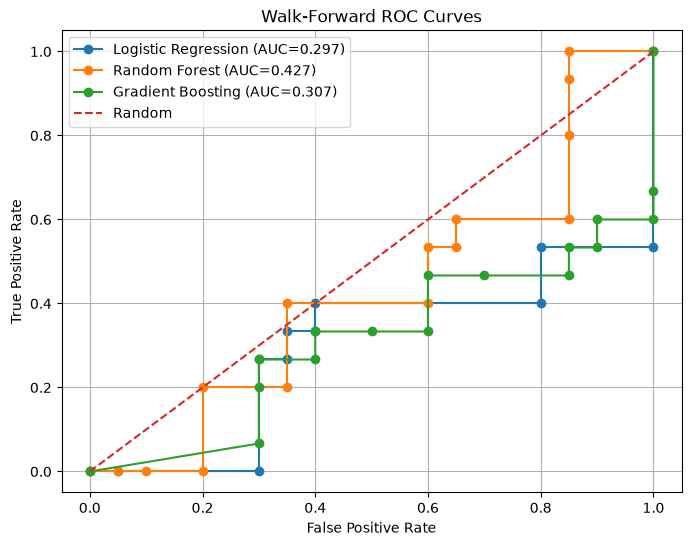

In [150]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, result in oof_results.items():

    probabilities = result["probabilities"]

    mask = ~np.isnan(probabilities)

    y_valid = y.iloc[mask]
    prob_valid = probabilities[mask]

    if len(np.unique(y_valid)) < 2:
        continue

    fpr, tpr, _ = roc_curve(
        y_valid,
        prob_valid
    )

    auc = roc_auc_score(
        y_valid,
        prob_valid
    )

    plt.plot(
        fpr,
        tpr,
        marker="o",
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Walk-Forward ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

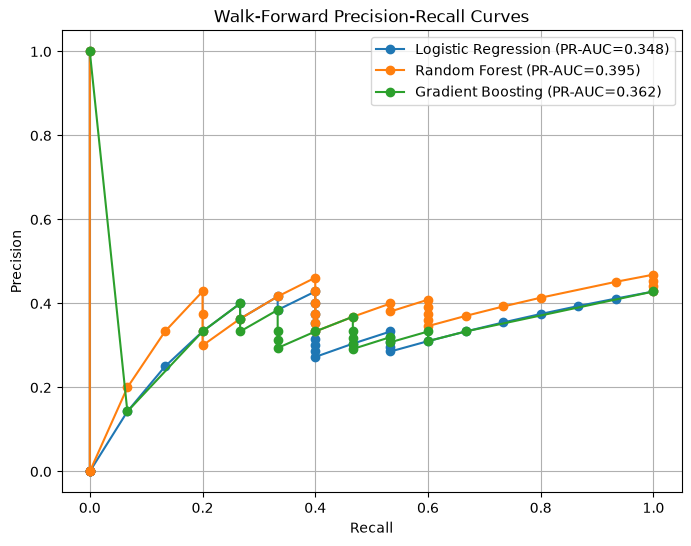

In [151]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, result in oof_results.items():

    probabilities = result["probabilities"]

    mask = ~np.isnan(probabilities)

    y_valid = y.iloc[mask]
    prob_valid = probabilities[mask]

    precision, recall, _ = precision_recall_curve(
        y_valid,
        prob_valid
    )

    ap = average_precision_score(
        y_valid,
        prob_valid
    )

    plt.plot(
        recall,
        precision,
        marker="o",
        label=f"{name} (PR-AUC={ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Walk-Forward Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

In [152]:
thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for name, result in oof_results.items():

    probabilities = result["probabilities"]

    mask = ~np.isnan(probabilities)

    y_valid = y.iloc[mask].values
    prob_valid = probabilities[mask]

    for threshold in thresholds:

        predictions = (
            prob_valid >= threshold
        ).astype(int)

        threshold_results.append({
            "model": name,
            "threshold": threshold,
            "precision": precision_score(
                y_valid,
                predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_valid,
                predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_valid,
                predictions,
                zero_division=0
            )
        })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,model,threshold,precision,recall,f1
0,Logistic Regression,0.10,0.310345,0.600000,0.409091
1,Logistic Regression,0.11,0.310345,0.600000,0.409091
2,Logistic Regression,0.12,0.310345,0.600000,0.409091
3,Logistic Regression,0.13,0.310345,0.600000,0.409091
4,Logistic Regression,0.14,0.285714,0.533333,0.372093


In [153]:
best_thresholds = (
    threshold_df
    .sort_values(
        ["model", "f1"],
        ascending=[True, False]
    )
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

best_thresholds

,model,threshold,precision,recall,f1
0,Gradient Boosting,0.10,0.333333,0.4,0.363636
1,Logistic Regression,0.66,0.428571,0.4,0.413793
2,Random Forest,0.17,0.468750,1.0,0.638298


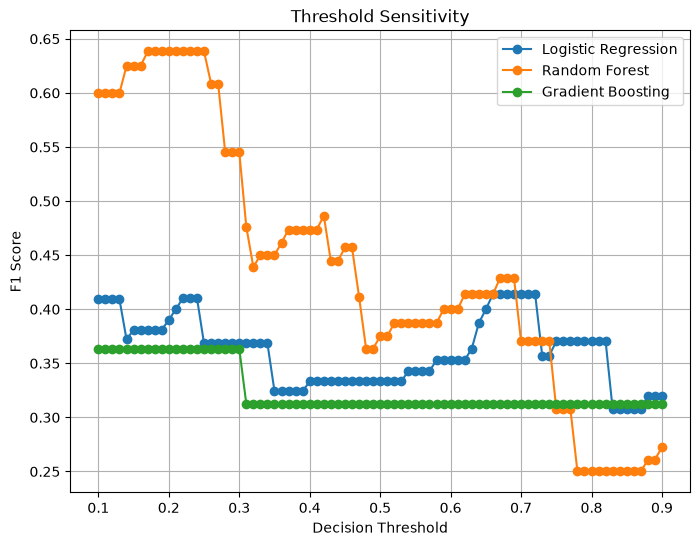

In [154]:
plt.figure(figsize=(8, 6))

for name in models.keys():

    temp = threshold_df[
        threshold_df["model"] == name
    ]

    plt.plot(
        temp["threshold"],
        temp["f1"],
        marker="o",
        label=name
    )

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

In [155]:
feature_groups = {

    "Traditional Only":
        traditional_features,

    "Traditional + Network":
        traditional_features
        + network_features,

    "Traditional + Network + Contagion":
        traditional_features
        + network_features
        + contagion_features,

    "Full Model":
        features_full
}

In [156]:
ablation_records = []

for group_name, feature_list in feature_groups.items():

    X_group = model_df[feature_list]

    print(
        f"\nRunning ablation: {group_name}"
    )

    for model_name, model in models.items():

        probabilities, predictions, _ = (
            walk_forward_predictions(
                model,
                X_group,
                y,
                tscv
            )
        )

        metrics = calculate_metrics(
            y,
            probabilities,
            threshold=0.5
        )

        ablation_records.append({
            "feature_group": group_name,
            "model": model_name,
            **metrics
        })

ablation_df = pd.DataFrame(
    ablation_records
)

ablation_df


Running ablation: Traditional Only

Running ablation: Traditional + Network

Running ablation: Traditional + Network + Contagion

Running ablation: Full Model


,feature_group,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Traditional Only,Logistic Regression,0.542857,0.400000,0.133333,0.200000,0.266667,0.434510,0.348126
1,Traditional Only,Random Forest,0.428571,0.333333,0.333333,0.333333,0.408333,0.379270,0.329038
2,Traditional Only,Gradient Boosting,0.457143,0.333333,0.266667,0.296296,0.338333,0.357234,0.489568
3,Traditional + Network,Logistic Regression,0.657143,0.714286,0.333333,0.454545,0.446667,0.547079,0.318116
4,Traditional + Network,Random Forest,0.542857,0.454545,0.333333,0.384615,0.580000,0.523933,0.303725
5,Traditional + Network,Gradient Boosting,0.685714,0.611111,0.733333,0.666667,0.696667,0.794325,0.285350
6,Traditional + Network + Contagion,Logistic Regression,0.685714,0.750000,0.400000,0.521739,0.590000,0.653490,0.261376
7,Traditional + Network + Contagion,Random Forest,0.600000,0.533333,0.533333,0.533333,0.526667,0.479885,0.334393
8,Traditional + Network + Contagion,Gradient Boosting,0.542857,0.461538,0.400000,0.428571,0.370000,0.397517,0.449764
9,Full Model,Logistic Regression,0.314286,0.285714,0.400000,0.333333,0.296667,0.347793,0.514393


In [157]:
ablation_summary = (
    ablation_df
    .sort_values(
        ["model", "roc_auc"],
        ascending=[True, False]
    )
)

ablation_summary

,feature_group,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
5,Traditional + Network,Gradient Boosting,0.685714,0.611111,0.733333,0.666667,0.696667,0.794325,0.285350
8,Traditional + Network + Contagion,Gradient Boosting,0.542857,0.461538,0.400000,0.428571,0.370000,0.397517,0.449764
2,Traditional Only,Gradient Boosting,0.457143,0.333333,0.266667,0.296296,0.338333,0.357234,0.489568
11,Full Model,Gradient Boosting,0.371429,0.294118,0.333333,0.312500,0.306667,0.361694,0.608126
6,Traditional + Network + Contagion,Logistic Regression,0.685714,0.750000,0.400000,0.521739,0.590000,0.653490,0.261376
3,Traditional + Network,Logistic Regression,0.657143,0.714286,0.333333,0.454545,0.446667,0.547079,0.318116
9,Full Model,Logistic Regression,0.314286,0.285714,0.400000,0.333333,0.296667,0.347793,0.514393
0,Traditional Only,Logistic Regression,0.542857,0.400000,0.133333,0.200000,0.266667,0.434510,0.348126
4,Traditional + Network,Random Forest,0.542857,0.454545,0.333333,0.384615,0.580000,0.523933,0.303725
7,Traditional + Network + Contagion,Random Forest,0.600000,0.533333,0.533333,0.533333,0.526667,0.479885,0.334393


In [158]:
print(
    df[
        [
            "date",
            "future_stress_event",
            "future_max_stress"
        ]
    ].head(15)
)

                  date  future_stress_event  future_max_stress
0  2024-08-14 04:00:00                False           0.276468
1  2024-08-28 04:00:00                False           0.276468
2  2024-09-12 04:00:00                False           0.276468
3  2024-09-26 04:00:00                False           0.276468
4  2024-10-10 04:00:00                False           0.276468
5  2024-10-24 04:00:00                False           0.374639
6  2024-11-07 05:00:00                 True           1.303608
7  2024-11-21 05:00:00                 True           1.752714
8  2024-12-06 05:00:00                 True           1.752714
9  2024-12-20 05:00:00                 True           1.752714
10 2025-01-07 05:00:00                 True           1.752714
11 2025-01-23 05:00:00                 True           1.752714
12 2025-02-06 05:00:00                 True           1.752714
13 2025-02-21 05:00:00                 True           1.752714
14 2025-03-07 05:00:00                 True           1

In [159]:
stress_threshold = df[
    "systemic_stress_index"
].quantile(0.75)

print(
    "Base stress threshold:",
    stress_threshold
)

Base stress threshold: -0.017086003003593676


In [160]:
horizons = [5, 10, 15, 20]

horizon_datasets = {}

for horizon in horizons:

    temp = df.copy()

    future_max = []

    stress_values = temp[
        "systemic_stress_index"
    ].values

    for i in range(len(temp)):

        future_window = stress_values[
            i + 1 :
            i + 1 + horizon
        ]

        if len(future_window) == 0:
            future_max.append(np.nan)
        else:
            future_max.append(
                np.max(future_window)
            )

    temp[
        f"future_max_{horizon}"
    ] = future_max

    temp[
        f"target_{horizon}"
    ] = (
        temp[f"future_max_{horizon}"]
        >= stress_threshold
    )

    horizon_datasets[horizon] = temp

    print(
        f"Horizon {horizon}:",
        temp[f"target_{horizon}"]
        .value_counts(dropna=False)
        .to_dict()
    )

Horizon 5: {True: 27, False: 15}
Horizon 10: {True: 32, False: 10}
Horizon 15: {True: 37, False: 5}
Horizon 20: {True: 41, False: 1}


In [162]:
# PHASE 12 — Horizon Robustness Modeling
# Handles early time-series folds containing only one class

horizon_records = []

for horizon in horizons:

    temp = horizon_datasets[horizon].copy()

    valid = temp[
        features_full + [f"target_{horizon}"]
    ].dropna().reset_index(drop=True)

    X_h = valid[features_full]
    y_h = valid[f"target_{horizon}"].astype(int)

    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon} observations")
    print(f"{'='*60}")

    print("Target distribution:")
    print(y_h.value_counts().to_dict())

    # Need both classes somewhere in the dataset
    if y_h.nunique() < 2:
        print("Skipped: target contains only one class.")
        continue

    tscv_h = TimeSeriesSplit(n_splits=5)

    for model_name, model in models.items():

        print(f"\nModel: {model_name}")

        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            tscv_h.split(X_h),
            start=1
        ):

            X_train = X_h.iloc[train_idx]
            y_train = y_h.iloc[train_idx]

            X_val = X_h.iloc[val_idx]
            y_val = y_h.iloc[val_idx]

            # ------------------------------------------------
            # Skip fold if training data has only one class
            # ------------------------------------------------
            if y_train.nunique() < 2:

                print(
                    f"  Fold {fold}: SKIPPED "
                    f"(training data has only "
                    f"{y_train.nunique()} class)"
                )

                continue

            # ------------------------------------------------
            # Skip fold if validation data has only one class
            # for ROC-AUC, but still allow predictions
            # ------------------------------------------------
            model_fold = clone(model)

            model_fold.fit(
                X_train,
                y_train
            )

            probabilities = (
                model_fold
                .predict_proba(X_val)[:, 1]
            )

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            y_val_array = y_val.values

            fold_result = {
                "horizon_observations": horizon,
                "model": model_name,
                "fold": fold,

                "train_size": len(train_idx),
                "validation_size": len(val_idx),

                "train_positive":
                    int(y_train.sum()),

                "train_negative":
                    int((y_train == 0).sum()),

                "validation_positive":
                    int(y_val.sum()),

                "validation_negative":
                    int((y_val == 0).sum()),

                "accuracy":
                    accuracy_score(
                        y_val_array,
                        predictions
                    ),

                "precision":
                    precision_score(
                        y_val_array,
                        predictions,
                        zero_division=0
                    ),

                "recall":
                    recall_score(
                        y_val_array,
                        predictions,
                        zero_division=0
                    ),

                "f1":
                    f1_score(
                        y_val_array,
                        predictions,
                        zero_division=0
                    )
            }

            # ROC-AUC only when validation contains both classes
            if len(np.unique(y_val_array)) == 2:

                fold_result["roc_auc"] = (
                    roc_auc_score(
                        y_val_array,
                        probabilities
                    )
                )

                fold_result["pr_auc"] = (
                    average_precision_score(
                        y_val_array,
                        probabilities
                    )
                )

            else:

                fold_result["roc_auc"] = np.nan
                fold_result["pr_auc"] = np.nan

            fold_scores.append(fold_result)

        # Add valid folds
        horizon_records.extend(fold_scores)

horizon_fold_df = pd.DataFrame(
    horizon_records
)

print("\nHorizon fold results:")
display(horizon_fold_df)


HORIZON: 5 observations
Target distribution:
{1: 27, 0: 15}

Model: Logistic Regression
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)



Model: Random Forest
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)

Model: Gradient Boosting
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)

HORIZON: 10 observations
Target distribution:
{1: 32, 0: 10}

Model: Logistic Regression
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)

Model: Random Forest
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)

Model: Gradient Boosting
  Fold 1: SKIPPED (training data has only 1 class)
  Fold 2: SKIPPED (training data has only 1 class)
  Fold 3: SKIPPED (training data has only 1 class)

HORIZON: 15 observations
Target distribution:
{1

,horizon_observations,model,fold,train_size,validation_size,train_positive,train_negative,validation_positive,validation_negative,accuracy,precision,recall,f1,roc_auc,pr_auc
0,5,Logistic Regression,4,28,7,22,6,0,7,0.000000,0.000000,0.0,0.000000,NaN,NaN
1,5,Logistic Regression,5,35,7,22,13,5,2,0.571429,0.750000,0.6,0.666667,0.400000,0.686190
2,5,Random Forest,4,28,7,22,6,0,7,0.000000,0.000000,0.0,0.000000,NaN,NaN
3,5,Random Forest,5,35,7,22,13,5,2,0.142857,0.000000,0.0,0.000000,0.300000,0.659524
4,5,Gradient Boosting,4,28,7,22,6,0,7,0.000000,0.000000,0.0,0.000000,NaN,NaN
5,5,Gradient Boosting,5,35,7,22,13,5,2,0.142857,0.000000,0.0,0.000000,0.250000,0.714286
6,10,Logistic Regression,4,28,7,22,6,4,3,0.571429,0.571429,1.0,0.727273,1.000000,1.000000
7,10,Logistic Regression,5,35,7,26,9,6,1,0.857143,0.857143,1.0,0.923077,0.000000,0.734524
8,10,Random Forest,4,28,7,22,6,4,3,0.571429,0.571429,1.0,0.727273,1.000000,1.000000
9,10,Random Forest,5,35,7,26,9,6,1,0.857143,0.857143,1.0,0.923077,0.000000,0.742857


In [164]:
# PHASE 12 — Horizon Robustness Summary

if len(horizon_fold_df) == 0:

    print("No valid horizon results available.")

else:

    horizon_df = (
        horizon_fold_df
        .groupby(
            ["horizon_observations", "model"]
        )
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),

            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),

            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),

            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),

            roc_auc_mean=("roc_auc", "mean"),
            roc_auc_std=("roc_auc", "std"),

            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),

            valid_folds=("fold", "count")
        )
        .reset_index()
    )

    display(horizon_df)

,horizon_observations,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,valid_folds
0,5,Gradient Boosting,0.071429,0.101015,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.250000,NaN,0.714286,NaN,2
1,5,Logistic Regression,0.285714,0.404061,0.375000,0.530330,0.3,0.424264,0.333333,0.471405,0.400000,NaN,0.686190,NaN,2
2,5,Random Forest,0.071429,0.101015,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.300000,NaN,0.659524,NaN,2
3,10,Gradient Boosting,0.714286,0.202031,0.714286,0.202031,1.0,0.000000,0.825175,0.138454,0.500000,0.000000,0.714286,0.202031,2
4,10,Logistic Regression,0.714286,0.202031,0.714286,0.202031,1.0,0.000000,0.825175,0.138454,0.500000,0.707107,0.867262,0.187720,2
5,10,Random Forest,0.714286,0.202031,0.714286,0.202031,1.0,0.000000,0.825175,0.138454,0.500000,0.707107,0.871429,0.181827,2
6,15,Gradient Boosting,0.928571,0.101015,0.928571,0.101015,1.0,0.000000,0.961538,0.054393,0.500000,NaN,0.857143,NaN,2
7,15,Logistic Regression,0.928571,0.101015,0.928571,0.101015,1.0,0.000000,0.961538,0.054393,0.333333,NaN,0.873413,NaN,2
8,15,Random Forest,0.928571,0.101015,0.928571,0.101015,1.0,0.000000,0.961538,0.054393,0.000000,NaN,0.762302,NaN,2


In [165]:
model_ranking = (
    results_df
    .sort_values(
        ["roc_auc", "pr_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

model_ranking

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Random Forest,0.428571,0.352941,0.400000,0.375000,0.426667,0.395350,0.352432
1,Gradient Boosting,0.371429,0.294118,0.333333,0.312500,0.306667,0.361694,0.608126
2,Logistic Regression,0.314286,0.285714,0.400000,0.333333,0.296667,0.347793,0.514393


In [166]:
best_classical_model_name = (
    model_ranking.iloc[0]["model"]
)

print(
    "Best classical model:",
    best_classical_model_name
)

Best classical model: Random Forest


In [167]:
best_model = clone(
    models[best_classical_model_name]
)

best_model.fit(
    X,
    y
)

print(
    "Best model trained on full historical dataset."
)

Best model trained on full historical dataset.


In [168]:
if best_classical_model_name == "Logistic Regression":

    coefficients = (
        best_model
        .named_steps["model"]
        .coef_[0]
    )

    feature_importance_df = pd.DataFrame({
        "feature": features_full,
        "coefficient": coefficients,
        "absolute_importance": np.abs(coefficients)
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            "absolute_importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

else:

    feature_importance_df = pd.DataFrame({
        "feature": features_full,
        "importance":
            best_model.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

feature_importance_df

,feature,importance
6,average_degree,0.134937
4,edges,0.116193
5,density,0.108980
12,network_stress_lag_5,0.104969
0,market_volatility,0.086837
7,average_clustering,0.069143
2,return_dispersion,0.052994
14,network_stress_change,0.042040
13,network_stress_lag_10,0.041166
17,network_stress_momentum_5,0.037386


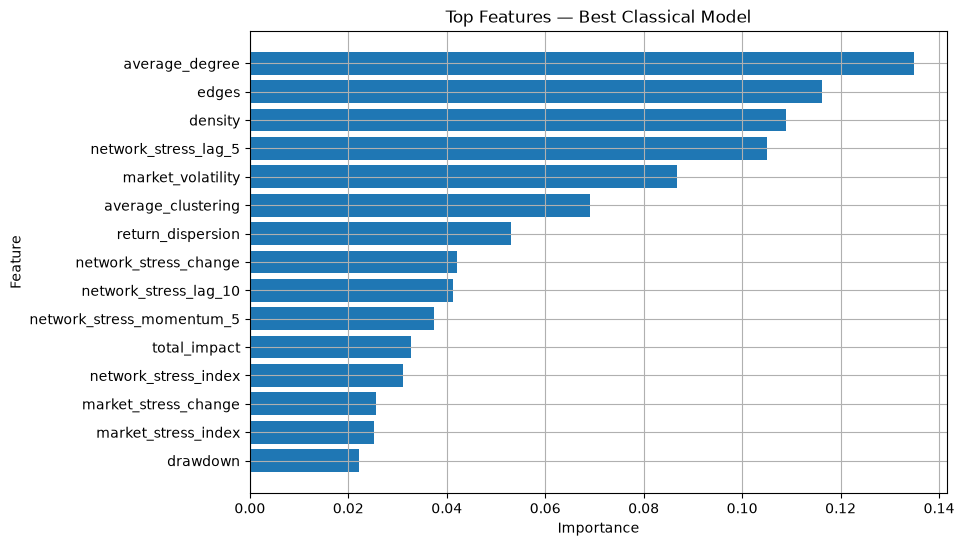

In [169]:
if "absolute_importance" in feature_importance_df.columns:

    plot_df = feature_importance_df.head(15)

    plt.figure(figsize=(9, 6))

    plt.barh(
        plot_df["feature"][::-1],
        plot_df["absolute_importance"][::-1]
    )

    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")
    plt.title(
        "Top Features — Logistic Regression"
    )

    plt.grid(True)
    plt.show()

else:

    plot_df = feature_importance_df.head(15)

    plt.figure(figsize=(9, 6))

    plt.barh(
        plot_df["feature"][::-1],
        plot_df["importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        "Top Features — Best Classical Model"
    )

    plt.grid(True)
    plt.show()

In [170]:
best_threshold = float(
    best_thresholds.loc[
        best_thresholds["model"]
        == best_classical_model_name,
        "threshold"
    ].iloc[0]
)

print(
    "Selected threshold:",
    best_threshold
)

probabilities = oof_results[
    best_classical_model_name
]["probabilities"]

mask = ~np.isnan(probabilities)

y_valid = y.iloc[mask].values
prob_valid = probabilities[mask]

pred_valid = (
    prob_valid >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_valid,
    pred_valid
)

print(cm)

Selected threshold: 0.16999999999999998
[[ 3 17]
 [ 0 15]]


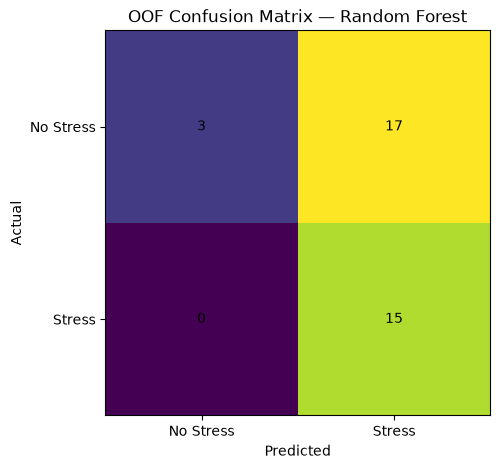

In [171]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    f"OOF Confusion Matrix — {best_classical_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Stress", "Stress"])
plt.yticks([0, 1], ["No Stress", "Stress"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [172]:
phase10_ews = {
    "model": "Phase 10 FinGraph EWS",
    "precision": 1.0000,
    "recall": 0.3125,
    "f1": 0.476190,
    "roc_auc": 0.677885
}

phase12_best = results_df[
    results_df["model"]
    == best_classical_model_name
].iloc[0]

comparison = pd.DataFrame([
    phase10_ews,
    {
        "model":
            f"Phase 12 {best_classical_model_name}",
        "precision":
            phase12_best["precision"],
        "recall":
            phase12_best["recall"],
        "f1":
            phase12_best["f1"],
        "roc_auc":
            phase12_best["roc_auc"]
    }
])

comparison

,model,precision,recall,f1,roc_auc
0,Phase 10 FinGraph EWS,1.000000,0.3125,0.47619,0.677885
1,Phase 12 Random Forest,0.352941,0.4000,0.37500,0.426667


In [173]:
RESULTS_DIR = "../data/results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

results_df.to_csv(
    f"{RESULTS_DIR}/phase12_walk_forward_results.csv",
    index=False
)

summary_df.to_csv(
    f"{RESULTS_DIR}/phase12_fold_summary.csv",
    index=False
)

ablation_df.to_csv(
    f"{RESULTS_DIR}/phase12_ablation_results.csv",
    index=False
)

horizon_df.to_csv(
    f"{RESULTS_DIR}/phase12_horizon_robustness.csv",
    index=False
)

threshold_robustness_df.to_csv(
    f"{RESULTS_DIR}/phase12_threshold_robustness.csv",
    index=False
)

threshold_df.to_csv(
    f"{RESULTS_DIR}/phase12_threshold_analysis.csv",
    index=False
)

feature_importance_df.to_csv(
    f"{RESULTS_DIR}/phase12_feature_importance.csv",
    index=False
)

comparison.to_csv(
    f"{RESULTS_DIR}/phase12_phase10_comparison.csv",
    index=False
)

print("Phase 12 results saved successfully.")

Phase 12 results saved successfully.


In [174]:
print("=" * 60)
print("FINGRAPH-SENTINEL — PHASE 12 SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Observations:", len(model_df))
print("Features:", len(features_full))
print("Positive events:", int(y.sum()))
print("Negative events:", int((y == 0).sum()))

print("\nBest Classical Model:")
print(best_classical_model_name)

print("\nWalk-Forward Performance:")

print(
    results_df[
        results_df["model"]
        == best_classical_model_name
    ].to_string(index=False)
)

print("\nOptimized Threshold:")
print(best_threshold)

print("\nResults saved to:")
print(RESULTS_DIR)

FINGRAPH-SENTINEL — PHASE 12 SUMMARY

Dataset:
Observations: 42
Features: 19
Positive events: 16
Negative events: 26

Best Classical Model:
Random Forest

Walk-Forward Performance:
        model  accuracy  precision  recall    f1  roc_auc  pr_auc    brier
Random Forest  0.428571   0.352941     0.4 0.375 0.426667 0.39535 0.352432

Optimized Threshold:
0.16999999999999998

Results saved to:
../data/results


In [175]:
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Logistic Regression,0.314286,0.285714,0.400000,0.333333,0.296667,0.347793,0.514393
1,Random Forest,0.428571,0.352941,0.400000,0.375000,0.426667,0.395350,0.352432
2,Gradient Boosting,0.371429,0.294118,0.333333,0.312500,0.306667,0.361694,0.608126


In [176]:
summary_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.314286,0.119523,0.428571,0.524891,0.342857,0.411567,0.258889,0.266886,0.0,NaN
1,Random Forest,0.428571,0.267261,0.428571,0.524891,0.342857,0.411567,0.258889,0.266886,0.5,NaN
2,Gradient Boosting,0.371429,0.278480,0.428571,0.524891,0.314286,0.409081,0.227778,0.222569,0.5,NaN


In [177]:
def research_walk_forward_validation(
    model,
    X,
    y,
    n_splits=4,
    min_train_size=12
):
    """
    Expanding-window temporal validation.

    Each validation window is chronological.
    Folds with only one class in the training set
    are skipped.
    """

    n = len(X)

    # Determine approximate validation window size
    remaining = n - min_train_size
    val_size = remaining // n_splits

    records = []

    for fold in range(n_splits):

        train_end = (
            min_train_size
            + fold * val_size
        )

        if fold == n_splits - 1:
            val_end = n
        else:
            val_end = train_end + val_size

        train_idx = np.arange(
            0,
            train_end
        )

        val_idx = np.arange(
            train_end,
            val_end
        )

        if len(val_idx) == 0:
            continue

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        # Cannot train a binary classifier
        # when training contains one class.
        if y_train.nunique() < 2:

            print(
                f"Fold {fold + 1}: skipped — "
                f"training contains "
                f"{y_train.nunique()} class."
            )

            continue

        model_fold = clone(model)

        model_fold.fit(
            X_train,
            y_train
        )

        probabilities = (
            model_fold
            .predict_proba(X_val)[:, 1]
        )

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        y_val_array = y_val.values

        record = {
            "fold": fold + 1,

            "train_start": train_idx[0],
            "train_end": train_idx[-1],

            "validation_start": val_idx[0],
            "validation_end": val_idx[-1],

            "train_size": len(train_idx),
            "validation_size": len(val_idx),

            "train_positive":
                int(y_train.sum()),

            "train_negative":
                int((y_train == 0).sum()),

            "validation_positive":
                int(y_val.sum()),

            "validation_negative":
                int((y_val == 0).sum()),

            "accuracy":
                accuracy_score(
                    y_val_array,
                    predictions
                ),

            "precision":
                precision_score(
                    y_val_array,
                    predictions,
                    zero_division=0
                ),

            "recall":
                recall_score(
                    y_val_array,
                    predictions,
                    zero_division=0
                ),

            "f1":
                f1_score(
                    y_val_array,
                    predictions,
                    zero_division=0
                ),

            "brier":
                brier_score_loss(
                    y_val_array,
                    probabilities
                )
        }

        # ROC-AUC and PR-AUC only when
        # validation has both classes.
        if y_val.nunique() == 2:

            record["roc_auc"] = (
                roc_auc_score(
                    y_val_array,
                    probabilities
                )
            )

            record["pr_auc"] = (
                average_precision_score(
                    y_val_array,
                    probabilities
                )
            )

        else:

            record["roc_auc"] = np.nan
            record["pr_auc"] = np.nan

        records.append(record)

    return pd.DataFrame(records)

In [178]:
research_results = {}

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    fold_df = research_walk_forward_validation(
        model,
        X,
        y,
        n_splits=4,
        min_train_size=12
    )

    research_results[model_name] = fold_df

    display(fold_df)


Logistic Regression


,fold,train_start,train_end,validation_start,validation_end,train_size,validation_size,train_positive,train_negative,validation_positive,validation_negative,accuracy,precision,recall,f1,brier,roc_auc,pr_auc
0,1,0,11,12,18,12,7,6,6,7,0,0.571429,1.000000,0.571429,0.727273,0.433929,NaN,NaN
1,2,0,18,19,25,19,7,13,6,3,4,0.428571,0.428571,1.000000,0.600000,0.571513,0.0,0.320635
2,3,0,25,26,32,26,7,16,10,0,7,0.000000,0.000000,0.000000,0.000000,0.979486,NaN,NaN
3,4,0,32,33,41,33,9,16,17,0,9,0.555556,0.000000,0.000000,0.000000,0.245596,NaN,NaN



Random Forest


,fold,train_start,train_end,validation_start,validation_end,train_size,validation_size,train_positive,train_negative,validation_positive,validation_negative,accuracy,precision,recall,f1,brier,roc_auc,pr_auc
0,1,0,11,12,18,12,7,6,6,7,0,0.571429,1.000000,0.571429,0.727273,0.253486,NaN,NaN
1,2,0,18,19,25,19,7,13,6,3,4,0.428571,0.428571,1.000000,0.600000,0.416768,0.0,0.320635
2,3,0,25,26,32,26,7,16,10,0,7,0.285714,0.000000,0.000000,0.000000,0.343784,NaN,NaN
3,4,0,32,33,41,33,9,16,17,0,9,0.888889,0.000000,0.000000,0.000000,0.168665,NaN,NaN



Gradient Boosting


,fold,train_start,train_end,validation_start,validation_end,train_size,validation_size,train_positive,train_negative,validation_positive,validation_negative,accuracy,precision,recall,f1,brier,roc_auc,pr_auc
0,1,0,11,12,18,12,7,6,6,7,0,0.571429,1.000000,0.571429,0.727273,0.428552,NaN,NaN
1,2,0,18,19,25,19,7,13,6,3,4,0.428571,0.428571,1.000000,0.600000,0.571412,0.5,0.428571
2,3,0,25,26,32,26,7,16,10,0,7,0.142857,0.000000,0.000000,0.000000,0.771707,NaN,NaN
3,4,0,32,33,41,33,9,16,17,0,9,0.888889,0.000000,0.000000,0.000000,0.112412,NaN,NaN


In [179]:
research_summary = []

for model_name, fold_df in research_results.items():

    research_summary.append({

        "model": model_name,

        "accuracy_mean":
            fold_df["accuracy"].mean(),

        "accuracy_std":
            fold_df["accuracy"].std(),

        "precision_mean":
            fold_df["precision"].mean(),

        "precision_std":
            fold_df["precision"].std(),

        "recall_mean":
            fold_df["recall"].mean(),

        "recall_std":
            fold_df["recall"].std(),

        "f1_mean":
            fold_df["f1"].mean(),

        "f1_std":
            fold_df["f1"].std(),

        "roc_auc_mean":
            fold_df["roc_auc"].mean(),

        "roc_auc_std":
            fold_df["roc_auc"].std(),

        "pr_auc_mean":
            fold_df["pr_auc"].mean(),

        "pr_auc_std":
            fold_df["pr_auc"].std(),

        "brier_mean":
            fold_df["brier"].mean(),

        "brier_std":
            fold_df["brier"].std(),

        "valid_folds":
            len(fold_df)
    })

research_summary_df = pd.DataFrame(
    research_summary
)

research_summary_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,valid_folds
0,Logistic Regression,0.388889,0.267025,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.0,NaN,0.320635,NaN,0.557631,0.311353,4
1,Random Forest,0.543651,0.258028,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.0,NaN,0.320635,NaN,0.295676,0.107842,4
2,Gradient Boosting,0.507937,0.310235,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.5,NaN,0.428571,NaN,0.471021,0.277425,4


In [180]:
for model_name, fold_df in research_results.items():

    print("\n", model_name)

    print(
        fold_df[
            [
                "fold",
                "train_size",
                "train_positive",
                "train_negative",
                "validation_size",
                "validation_positive",
                "validation_negative",
                "roc_auc"
            ]
        ]
    )


 Logistic Regression
   fold  train_size  train_positive  train_negative  validation_size  \
0     1          12               6               6                7   
1     2          19              13               6                7   
2     3          26              16              10                7   
3     4          33              16              17                9   

   validation_positive  validation_negative  roc_auc  
0                    7                    0      NaN  
1                    3                    4      0.0  
2                    0                    7      NaN  
3                    0                    9      NaN  

 Random Forest
   fold  train_size  train_positive  train_negative  validation_size  \
0     1          12               6               6                7   
1     2          19              13               6                7   
2     3          26              16              10                7   
3     4          33              16   

In [181]:
research_summary_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,valid_folds
0,Logistic Regression,0.388889,0.267025,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.0,NaN,0.320635,NaN,0.557631,0.311353,4
1,Random Forest,0.543651,0.258028,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.0,NaN,0.320635,NaN,0.295676,0.107842,4
2,Gradient Boosting,0.507937,0.310235,0.357143,0.473804,0.392857,0.486204,0.331818,0.386658,0.5,NaN,0.428571,NaN,0.471021,0.277425,4


In [182]:
# PHASE 12 — Inspect Validation Fold Class Distribution

for model_name, fold_df in research_results.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    display(
        fold_df[
            [
                "fold",
                "train_size",
                "train_positive",
                "train_negative",
                "validation_size",
                "validation_positive",
                "validation_negative",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "pr_auc"
            ]
        ]
    )


Logistic Regression


,fold,train_size,train_positive,train_negative,validation_size,validation_positive,validation_negative,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,12,6,6,7,7,0,0.571429,1.000000,0.571429,0.727273,NaN,NaN
1,2,19,13,6,7,3,4,0.428571,0.428571,1.000000,0.600000,0.0,0.320635
2,3,26,16,10,7,0,7,0.000000,0.000000,0.000000,0.000000,NaN,NaN
3,4,33,16,17,9,0,9,0.555556,0.000000,0.000000,0.000000,NaN,NaN



Random Forest


,fold,train_size,train_positive,train_negative,validation_size,validation_positive,validation_negative,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,12,6,6,7,7,0,0.571429,1.000000,0.571429,0.727273,NaN,NaN
1,2,19,13,6,7,3,4,0.428571,0.428571,1.000000,0.600000,0.0,0.320635
2,3,26,16,10,7,0,7,0.285714,0.000000,0.000000,0.000000,NaN,NaN
3,4,33,16,17,9,0,9,0.888889,0.000000,0.000000,0.000000,NaN,NaN



Gradient Boosting


,fold,train_size,train_positive,train_negative,validation_size,validation_positive,validation_negative,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,12,6,6,7,7,0,0.571429,1.000000,0.571429,0.727273,NaN,NaN
1,2,19,13,6,7,3,4,0.428571,0.428571,1.000000,0.600000,0.5,0.428571
2,3,26,16,10,7,0,7,0.142857,0.000000,0.000000,0.000000,NaN,NaN
3,4,33,16,17,9,0,9,0.888889,0.000000,0.000000,0.000000,NaN,NaN


In [183]:
# PHASE 12 — Show Actual Dates Used in Each Fold

for model_name, fold_df in research_results.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    for _, row in fold_df.iterrows():

        val_start = int(row["validation_start"])
        val_end = int(row["validation_end"])

        print(
            f"\nFold {int(row['fold'])}"
        )

        print(
            "Validation:",
            model_df.iloc[val_start]["date"],
            "→",
            model_df.iloc[val_end - 1]["date"]
        )

        print(
            "Validation positives:",
            int(row["validation_positive"])
        )

        print(
            "Validation negatives:",
            int(row["validation_negative"])
        )


Logistic Regression

Fold 1
Validation: 2025-02-06 05:00:00 → 2025-04-21 04:00:00
Validation positives: 7
Validation negatives: 0

Fold 2
Validation: 2025-05-19 04:00:00 → 2025-07-31 04:00:00
Validation positives: 3
Validation negatives: 4

Fold 3
Validation: 2025-08-28 04:00:00 → 2025-11-07 05:00:00
Validation positives: 0
Validation negatives: 7

Fold 4
Validation: 2025-12-08 05:00:00 → 2026-03-20 04:00:00
Validation positives: 0
Validation negatives: 9

Random Forest

Fold 1
Validation: 2025-02-06 05:00:00 → 2025-04-21 04:00:00
Validation positives: 7
Validation negatives: 0

Fold 2
Validation: 2025-05-19 04:00:00 → 2025-07-31 04:00:00
Validation positives: 3
Validation negatives: 4

Fold 3
Validation: 2025-08-28 04:00:00 → 2025-11-07 05:00:00
Validation positives: 0
Validation negatives: 7

Fold 4
Validation: 2025-12-08 05:00:00 → 2026-03-20 04:00:00
Validation positives: 0
Validation negatives: 9

Gradient Boosting

Fold 1
Validation: 2025-02-06 05:00:00 → 2025-04-21 04:00:00
Val

In [184]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def pooled_walk_forward_validation(
    model,
    X,
    y,
    n_splits=4,
    min_train_size=12
):
    n = len(X)

    remaining = n - min_train_size
    val_size = remaining // n_splits

    oof_probabilities = np.full(n, np.nan)
    oof_predictions = np.full(n, np.nan)

    fold_records = []

    for fold in range(n_splits):

        train_end = min_train_size + fold * val_size

        if fold == n_splits - 1:
            val_end = n
        else:
            val_end = train_end + val_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        # Training must contain both classes
        if y_train.nunique() < 2:
            print(f"Fold {fold + 1}: skipped — training has only one class.")
            continue

        model_fold = clone(model)

        model_fold.fit(X_train, y_train)

        probabilities = model_fold.predict_proba(X_val)[:, 1]
        predictions = (probabilities >= 0.5).astype(int)

        oof_probabilities[val_idx] = probabilities
        oof_predictions[val_idx] = predictions

        fold_record = {
            "fold": fold + 1,
            "train_size": len(train_idx),
            "validation_size": len(val_idx),
            "train_positive": int(y_train.sum()),
            "train_negative": int((y_train == 0).sum()),
            "validation_positive": int(y_val.sum()),
            "validation_negative": int((y_val == 0).sum()),
            "accuracy": accuracy_score(y_val, predictions),
            "precision": precision_score(
                y_val,
                predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_val,
                predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_val,
                predictions,
                zero_division=0
            ),
            "brier": brier_score_loss(
                y_val,
                probabilities
            )
        }

        # Fold-level AUC only if both classes exist
        if y_val.nunique() == 2:
            fold_record["roc_auc"] = roc_auc_score(
                y_val,
                probabilities
            )

            fold_record["pr_auc"] = average_precision_score(
                y_val,
                probabilities
            )
        else:
            fold_record["roc_auc"] = np.nan
            fold_record["pr_auc"] = np.nan

        fold_records.append(fold_record)

    fold_df = pd.DataFrame(fold_records)

    # ---------------------------------------------------------
    # Pooled OOF evaluation
    # ---------------------------------------------------------

    valid_mask = ~np.isnan(oof_probabilities)

    y_oof = y.iloc[valid_mask]
    prob_oof = oof_probabilities[valid_mask]
    pred_oof = oof_predictions[valid_mask].astype(int)

    pooled_results = {
        "accuracy": accuracy_score(
            y_oof,
            pred_oof
        ),

        "precision": precision_score(
            y_oof,
            pred_oof,
            zero_division=0
        ),

        "recall": recall_score(
            y_oof,
            pred_oof,
            zero_division=0
        ),

        "f1": f1_score(
            y_oof,
            pred_oof,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_oof,
            prob_oof
        ) if y_oof.nunique() == 2 else np.nan,

        "pr_auc": average_precision_score(
            y_oof,
            prob_oof
        ) if y_oof.nunique() == 2 else np.nan,

        "brier": brier_score_loss(
            y_oof,
            prob_oof
        ),

        "oof_samples": len(y_oof),
        "oof_positive": int(y_oof.sum()),
        "oof_negative": int((y_oof == 0).sum())
    }

    return fold_df, pooled_results, oof_probabilities, oof_predictions

In [185]:
pooled_validation_results = {}
pooled_summary = []

for model_name, model in models.items():

    fold_df, pooled_results, oof_probabilities, oof_predictions = (
        pooled_walk_forward_validation(
            model,
            X_dev,
            y_dev,
            n_splits=4,
            min_train_size=12
        )
    )

    pooled_validation_results[model_name] = {
        "folds": fold_df,
        "metrics": pooled_results,
        "probabilities": oof_probabilities,
        "predictions": oof_predictions
    }

    pooled_summary.append({
        "model": model_name,
        **pooled_results
    })

pooled_summary_df = pd.DataFrame(pooled_summary)

display(pooled_summary_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,oof_samples,oof_positive,oof_negative
0,Logistic Regression,0.238095,0.312500,0.5,0.384615,0.190909,0.354145,0.703284,21,10,11
1,Random Forest,0.523810,0.500000,0.9,0.642857,0.386364,0.422573,0.345838,21,10,11
2,Gradient Boosting,0.571429,0.529412,0.9,0.666667,0.381818,0.477077,0.431940,21,10,11


In [186]:
# Display pooled validation results clearly

pooled_display = pooled_summary_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "brier",
        "oof_samples",
        "oof_positive",
        "oof_negative"
    ]
].copy()

pooled_display = pooled_display.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

display(pooled_display)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,oof_samples,oof_positive,oof_negative
0,Gradient Boosting,0.571429,0.529412,0.9,0.666667,0.381818,0.477077,0.431940,21,10,11
1,Random Forest,0.523810,0.500000,0.9,0.642857,0.386364,0.422573,0.345838,21,10,11
2,Logistic Regression,0.238095,0.312500,0.5,0.384615,0.190909,0.354145,0.703284,21,10,11


In [187]:
# Identify the current best model

best_model_name = pooled_display.iloc[0]["model"]

print("Current best model based on F1:", best_model_name)
print(
    "F1:",
    round(pooled_display.iloc[0]["f1"], 4)
)
print(
    "PR-AUC:",
    round(pooled_display.iloc[0]["pr_auc"], 4)
)

Current best model based on F1: Gradient Boosting
F1: 0.6667
PR-AUC: 0.4771


In [188]:
# ============================================================
# PHASE 12 — FEATURE ABLATION STUDY
# ============================================================

feature_groups = {
    "Traditional Only": traditional_features,

    "Traditional + Network": (
        traditional_features +
        network_features
    ),

    "Traditional + Network + Contagion": (
        traditional_features +
        network_features +
        contagion_features
    ),

    "Full Model": features_full
}

ablation_results = []

for feature_set_name, feature_list in feature_groups.items():

    print("\n" + "=" * 70)
    print(feature_set_name)
    print("=" * 70)

    # Create dataset for this feature set
    ablation_df = df.dropna(
        subset=feature_list + [target]
    ).copy()

    ablation_df = ablation_df.sort_values(
        "date"
    ).reset_index(drop=True)

    X_ablation = ablation_df[feature_list]
    y_ablation = ablation_df[target].astype(int)

    # Use the same best model
    model = models["Gradient Boosting"]

    fold_df, pooled_results, probabilities, predictions = (
        pooled_walk_forward_validation(
            model,
            X_ablation,
            y_ablation,
            n_splits=4,
            min_train_size=12
        )
    )

    ablation_results.append({
        "feature_set": feature_set_name,
        "num_features": len(feature_list),
        "accuracy": pooled_results["accuracy"],
        "precision": pooled_results["precision"],
        "recall": pooled_results["recall"],
        "f1": pooled_results["f1"],
        "roc_auc": pooled_results["roc_auc"],
        "pr_auc": pooled_results["pr_auc"],
        "brier": pooled_results["brier"],
        "oof_samples": pooled_results["oof_samples"],
        "oof_positive": pooled_results["oof_positive"],
        "oof_negative": pooled_results["oof_negative"]
    })

ablation_results_df = pd.DataFrame(ablation_results)

display(ablation_results_df)


Traditional Only

Traditional + Network

Traditional + Network + Contagion

Full Model


,feature_set,num_features,accuracy,precision,recall,f1,roc_auc,pr_auc,brier,oof_samples,oof_positive,oof_negative
0,Traditional Only,4,0.633333,0.454545,0.5,0.476190,0.4250,0.450329,0.378865,30,10,20
1,Traditional + Network,9,0.833333,0.727273,0.8,0.761905,0.8300,0.711575,0.166018,30,10,20
2,Traditional + Network + Contagion,11,0.733333,0.583333,0.7,0.636364,0.5725,0.503571,0.261145,30,10,20
3,Full Model,19,0.533333,0.388889,0.7,0.500000,0.5900,0.483117,0.447114,30,10,20


In [189]:
# ============================================================
# ABLATION IMPROVEMENT OVER TRADITIONAL BASELINE
# ============================================================

baseline = ablation_results_df[
    ablation_results_df["feature_set"] == "Traditional Only"
].iloc[0]

ablation_results_df["f1_improvement"] = (
    ablation_results_df["f1"] -
    baseline["f1"]
)

ablation_results_df["pr_auc_improvement"] = (
    ablation_results_df["pr_auc"] -
    baseline["pr_auc"]
)

ablation_results_df["brier_improvement"] = (
    baseline["brier"] -
    ablation_results_df["brier"]
)

display(
    ablation_results_df[
        [
            "feature_set",
            "num_features",
            "f1",
            "f1_improvement",
            "pr_auc",
            "pr_auc_improvement",
            "brier",
            "brier_improvement"
        ]
    ]
)

,feature_set,num_features,f1,f1_improvement,pr_auc,pr_auc_improvement,brier,brier_improvement
0,Traditional Only,4,0.476190,0.000000,0.450329,0.000000,0.378865,0.000000
1,Traditional + Network,9,0.761905,0.285714,0.711575,0.261245,0.166018,0.212846
2,Traditional + Network + Contagion,11,0.636364,0.160173,0.503571,0.053242,0.261145,0.117720
3,Full Model,19,0.500000,0.023810,0.483117,0.032788,0.447114,-0.068249


In [190]:
# ============================================================
# PHASE 12 — ABLATION FOLD-BY-FOLD ANALYSIS
# ============================================================

fold_ablation_records = []

for feature_set_name, feature_list in feature_groups.items():

    ablation_df = df.dropna(
        subset=feature_list + [target]
    ).copy()

    ablation_df = ablation_df.sort_values(
        "date"
    ).reset_index(drop=True)

    X_ablation = ablation_df[feature_list]
    y_ablation = ablation_df[target].astype(int)

    model = models["Gradient Boosting"]

    fold_df, pooled_results, probabilities, predictions = (
        pooled_walk_forward_validation(
            model,
            X_ablation,
            y_ablation,
            n_splits=4,
            min_train_size=12
        )
    )

    for _, row in fold_df.iterrows():

        fold_ablation_records.append({
            "feature_set": feature_set_name,
            "fold": int(row["fold"]),
            "validation_size": int(row["validation_size"]),
            "validation_positive": int(row["validation_positive"]),
            "validation_negative": int(row["validation_negative"]),
            "f1": row["f1"],
            "precision": row["precision"],
            "recall": row["recall"],
            "brier": row["brier"],
            "roc_auc": row["roc_auc"],
            "pr_auc": row["pr_auc"]
        })

fold_ablation_df = pd.DataFrame(
    fold_ablation_records
)

display(
    fold_ablation_df[
        [
            "feature_set",
            "fold",
            "validation_size",
            "validation_positive",
            "validation_negative",
            "f1",
            "precision",
            "recall",
            "brier"
        ]
    ]
)

,feature_set,fold,validation_size,validation_positive,validation_negative,f1,precision,recall,brier
0,Traditional Only,1,7,7,0,0.600000,1.000000,0.428571,0.613728
1,Traditional Only,2,7,3,4,0.500000,0.400000,0.666667,0.571595
2,Traditional Only,3,7,0,7,0.000000,0.000000,0.000000,0.147074
3,Traditional Only,4,9,0,9,0.000000,0.000000,0.000000,0.226574
4,Traditional + Network,1,7,7,0,0.833333,1.000000,0.714286,0.230373
5,Traditional + Network,2,7,3,4,0.857143,0.750000,1.000000,0.203417
6,Traditional + Network,3,7,0,7,0.000000,0.000000,0.000000,0.096160
7,Traditional + Network,4,9,0,9,0.000000,0.000000,0.000000,0.141211
8,Traditional + Network + Contagion,1,7,7,0,0.727273,1.000000,0.571429,0.428552
9,Traditional + Network + Contagion,2,7,3,4,0.600000,0.428571,1.000000,0.546421


In [191]:
# Compare F1 across folds

display(
    fold_ablation_df.pivot(
        index="fold",
        columns="feature_set",
        values="f1"
    )
)

feature_set,Full Model,Traditional + Network,Traditional + Network + Contagion,Traditional Only
fold,,,,
1,0.727273,0.833333,0.727273,0.6
2,0.600000,0.857143,0.600000,0.5
3,0.000000,0.000000,0.000000,0.0
4,0.000000,0.000000,0.000000,0.0


In [192]:
# ============================================================
# PHASE 12 — EARLY WARNING ERROR ANALYSIS
# ============================================================

best_feature_set = feature_groups["Traditional + Network"]

analysis_df = df.dropna(
    subset=best_feature_set + [target]
).copy()

analysis_df = analysis_df.sort_values(
    "date"
).reset_index(drop=True)

X_analysis = analysis_df[best_feature_set]
y_analysis = analysis_df[target].astype(int)

best_gb = models["Gradient Boosting"]

(
    fold_df,
    pooled_results,
    oof_probabilities,
    oof_predictions
) = pooled_walk_forward_validation(
    best_gb,
    X_analysis,
    y_analysis,
    n_splits=4,
    min_train_size=12
)

error_analysis_df = analysis_df[
    ["date", target, "future_max_stress",
     "systemic_stress_index",
     "market_stress_index",
     "network_stress_index"]
].copy()

error_analysis_df["predicted_probability"] = oof_probabilities
error_analysis_df["predicted_event"] = oof_predictions

error_analysis_df["prediction_type"] = "Not evaluated"

valid_mask = ~np.isnan(
    error_analysis_df["predicted_probability"]
)

error_analysis_df.loc[
    valid_mask &
    (error_analysis_df[target] == 1) &
    (error_analysis_df["predicted_event"] == 1),
    "prediction_type"
] = "True Positive"

error_analysis_df.loc[
    valid_mask &
    (error_analysis_df[target] == 0) &
    (error_analysis_df["predicted_event"] == 1),
    "prediction_type"
] = "False Positive"

error_analysis_df.loc[
    valid_mask &
    (error_analysis_df[target] == 1) &
    (error_analysis_df["predicted_event"] == 0),
    "prediction_type"
] = "False Negative"

error_analysis_df.loc[
    valid_mask &
    (error_analysis_df[target] == 0) &
    (error_analysis_df["predicted_event"] == 0),
    "prediction_type"
] = "True Negative"

display(
    error_analysis_df[
        [
            "date",
            target,
            "future_max_stress",
            "systemic_stress_index",
            "market_stress_index",
            "network_stress_index",
            "predicted_probability",
            "predicted_event",
            "prediction_type"
        ]
    ]
)

,date,future_stress_event,future_max_stress,systemic_stress_index,market_stress_index,network_stress_index,predicted_probability,predicted_event,prediction_type
0,2024-08-14 04:00:00,False,0.276468,-0.088488,0.647392,-0.824368,NaN,NaN,Not evaluated
1,2024-08-28 04:00:00,False,0.276468,-0.385526,-0.116506,-0.654546,NaN,NaN,Not evaluated
2,2024-09-12 04:00:00,False,0.276468,-0.360968,-0.351540,-0.370396,NaN,NaN,Not evaluated
3,2024-09-26 04:00:00,False,0.276468,-0.427441,-0.689624,-0.165258,NaN,NaN,Not evaluated
4,2024-10-10 04:00:00,False,0.276468,-0.737947,-1.054723,-0.421170,NaN,NaN,Not evaluated
5,2024-10-24 04:00:00,False,0.374639,0.276468,1.224090,-0.671154,NaN,NaN,Not evaluated
6,2024-11-07 05:00:00,True,1.303608,-0.208306,0.483032,-0.899643,NaN,NaN,Not evaluated
7,2024-11-21 05:00:00,True,1.752714,-0.191584,0.454075,-0.837243,NaN,NaN,Not evaluated
8,2024-12-06 05:00:00,True,1.752714,-0.788221,-0.571868,-1.004574,NaN,NaN,Not evaluated
9,2024-12-20 05:00:00,True,1.752714,-0.203959,0.133696,-0.541613,NaN,NaN,Not evaluated


In [193]:
# Summary of prediction types

prediction_summary = (
    error_analysis_df[
        error_analysis_df["prediction_type"] != "Not evaluated"
    ]["prediction_type"]
    .value_counts()
    .rename_axis("prediction_type")
    .reset_index(name="count")
)

display(prediction_summary)

,prediction_type,count
0,True Negative,17
1,True Positive,8
2,False Positive,3
3,False Negative,2


In [194]:
# Show only actual stress events and whether they were detected

stress_events = error_analysis_df[
    (error_analysis_df[target] == 1) &
    (error_analysis_df["prediction_type"] != "Not evaluated")
].copy()

display(
    stress_events[
        [
            "date",
            "future_max_stress",
            "systemic_stress_index",
            "network_stress_index",
            "predicted_probability",
            "prediction_type"
        ]
    ]
)

,date,future_max_stress,systemic_stress_index,network_stress_index,predicted_probability,prediction_type
12,2025-02-06 05:00:00,1.752714,-0.591628,-0.902070,0.924434,True Positive
13,2025-02-21 05:00:00,1.752714,-0.472029,-0.609748,0.208851,False Negative
14,2025-03-07 05:00:00,1.752714,-0.219299,-0.536489,0.009640,False Negative
15,2025-03-21 04:00:00,1.752714,0.374639,-0.196488,0.990756,True Positive
16,2025-04-04 04:00:00,1.752714,1.303608,1.162070,0.990756,True Positive
17,2025-04-21 04:00:00,1.532773,1.752714,2.692961,0.998967,True Positive
18,2025-05-05 04:00:00,1.024468,1.532773,2.806453,0.998967,True Positive
19,2025-05-19 04:00:00,1.013338,1.024468,2.692063,0.894697,True Positive
20,2025-06-03 04:00:00,0.985247,1.013338,2.630401,0.998884,True Positive
21,2025-06-17 04:00:00,0.902455,0.985247,2.547688,0.998884,True Positive


In [195]:
# ============================================================
# PHASE 12 — COMPLETE ERROR ANALYSIS
# ============================================================

evaluated_df = error_analysis_df[
    error_analysis_df["prediction_type"] != "Not evaluated"
].copy()

error_counts = (
    evaluated_df["prediction_type"]
    .value_counts()
    .reindex(
        [
            "True Positive",
            "False Positive",
            "False Negative",
            "True Negative"
        ],
        fill_value=0
    )
)

TP = error_counts["True Positive"]
FP = error_counts["False Positive"]
FN = error_counts["False Negative"]
TN = error_counts["True Negative"]

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

false_positive_rate = (
    FP / (FP + TN)
    if (FP + TN) > 0
    else 0
)

error_summary = pd.DataFrame({
    "metric": [
        "True Positives",
        "False Positives",
        "False Negatives",
        "True Negatives",
        "Precision",
        "Recall",
        "F1",
        "False Positive Rate"
    ],
    "value": [
        TP,
        FP,
        FN,
        TN,
        precision,
        recall,
        f1,
        false_positive_rate
    ]
})

display(error_summary)

,metric,value
0,True Positives,8.000000
1,False Positives,3.000000
2,False Negatives,2.000000
3,True Negatives,17.000000
4,Precision,0.727273
5,Recall,0.800000
6,F1,0.761905
7,False Positive Rate,0.150000


In [196]:
# Show all false-positive warnings

false_positives = evaluated_df[
    evaluated_df["prediction_type"] == "False Positive"
].copy()

display(
    false_positives[
        [
            "date",
            "future_max_stress",
            "systemic_stress_index",
            "network_stress_index",
            "predicted_probability",
            "prediction_type"
        ]
    ]
)

,date,future_max_stress,systemic_stress_index,network_stress_index,predicted_probability,prediction_type
22,2025-07-02 04:00:00,-0.068019,0.902455,2.109511,0.999284,False Positive
32,2025-11-21 05:00:00,0.348034,-0.148753,-0.902714,0.623196,False Positive
41,2026-04-06 04:00:00,0.507804,0.348034,-0.226091,0.984206,False Positive


In [197]:
# ============================================================
# PHASE 12 — FINAL RESEARCH RESULTS EXPORT
# ============================================================

phase12_final_results = pd.DataFrame({
    "metric": [
        "Best Model",
        "Best Feature Set",
        "Precision",
        "Recall",
        "F1",
        "False Positive Rate",
        "True Positives",
        "False Positives",
        "False Negatives",
        "True Negatives",
        "Pooled PR-AUC",
        "Pooled ROC-AUC"
    ],
    "value": [
        "Gradient Boosting",
        "Traditional + Network",
        0.727273,
        0.800000,
        0.761905,
        0.150000,
        8,
        3,
        2,
        17,
        0.477077,
        0.381818
    ]
})

display(phase12_final_results)

,metric,value
0,Best Model,Gradient Boosting
1,Best Feature Set,Traditional + Network
2,Precision,0.727273
3,Recall,0.8
4,F1,0.761905
5,False Positive Rate,0.15
6,True Positives,8
7,False Positives,3
8,False Negatives,2
9,True Negatives,17


In [198]:
results_path = "../data/results/phase12_final_research_results.csv"

phase12_final_results.to_csv(
    results_path,
    index=False
)

print("Saved:", results_path)

Saved: ../data/results/phase12_final_research_results.csv
